# Comprehensive EDA & Data Cleaning Assignment
### Datasets: Loan Eligibility | Adult Census Income | Hotel Booking

This notebook performs a complete Exploratory Data Analysis (EDA) and Data Cleaning workflow on three datasets, one after another:

1. **Loan Eligibility Dataset**
2. **Adult Census Income Dataset**
3. **Hotel Booking Dataset**

For every dataset we cover:
- Data loading & structure inspection
- Missing value analysis
- Univariate analysis (every column) with visualizations
- Bivariate analysis against the target/key variable
- Outlier detection
- Data cleaning (imputation, duplicate removal, type fixes, outlier handling)
- Correlation analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Libraries imported successfully.")


Libraries imported successfully.


---
# Dataset 1: Loan Eligibility Dataset
---
This dataset contains information about loan applicants and whether their loan was approved (`Loan_Status`).


## 1.1 Load Data & Initial Inspection

In [2]:
loan = pd.read_csv('loan-train__1_.csv')
print("Shape:", loan.shape)
loan.head()


Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
loan.info()


<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 164.1 KB


In [4]:
loan.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,1614,1538,LP006706,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1601,2,Male,980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,1611,2,Yes,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,1599,4,0,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1614,2,Graduate,952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,1582,2,No,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,1614.0,NaN,NaN,NaN,8746.304833,6249.885122,150.0,3675.25,7045.0,13251.0,81000.0
CoapplicantIncome,1614.0,NaN,NaN,NaN,3658.722999,3291.745935,0.0,986.25,2941.5,5893.0,41667.0
LoanAmount,1592.0,NaN,NaN,NaN,218.846734,133.623293,9.0,112.0,180.0,324.0,700.0
Loan_Amount_Term,1600.0,NaN,NaN,NaN,290.475,81.899735,12.0,240.0,360.0,360.0,480.0


## 1.2 Missing Value Analysis

In [5]:
missing_loan = loan.isnull().sum()
missing_pct = (missing_loan / len(loan)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_loan, 'Missing_%': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_df


,Missing_Count,Missing_%
Credit_History,50,3.10
Self_Employed,32,1.98
LoanAmount,22,1.36
Dependents,15,0.93
Loan_Amount_Term,14,0.87
Gender,13,0.81
Married,3,0.19


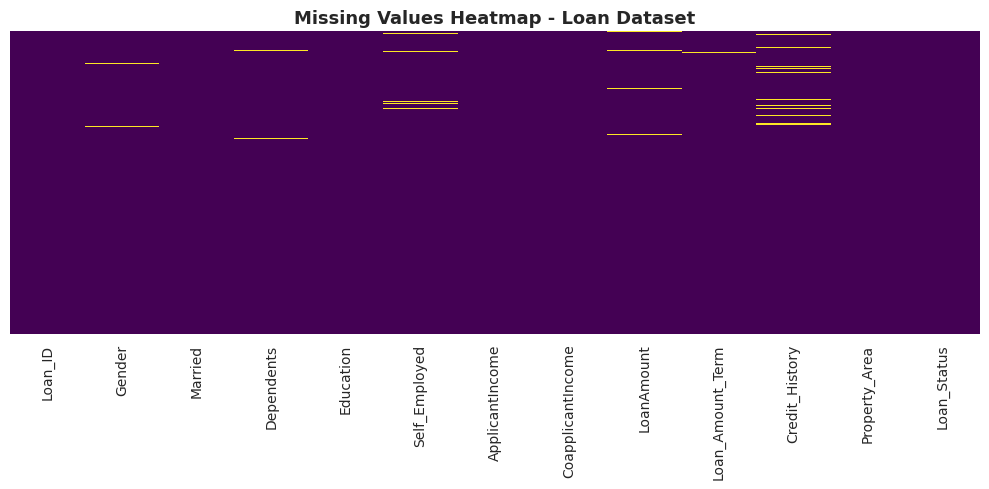

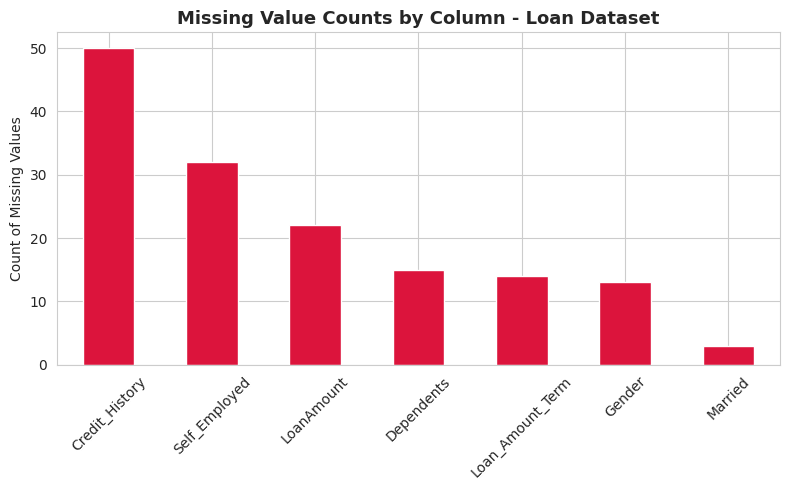

In [6]:
plt.figure(figsize=(10, 5))
sns.heatmap(loan.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap - Loan Dataset')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
missing_df['Missing_Count'].plot(kind='bar', color='crimson')
plt.title('Missing Value Counts by Column - Loan Dataset')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 1.3 Duplicate Check

In [7]:
print("Duplicate rows in Loan dataset:", loan.duplicated().sum())


Duplicate rows in Loan dataset: 0


## 1.4 Univariate Analysis (Every Column)

We separate columns into categorical and numerical, and visualize each one individually.


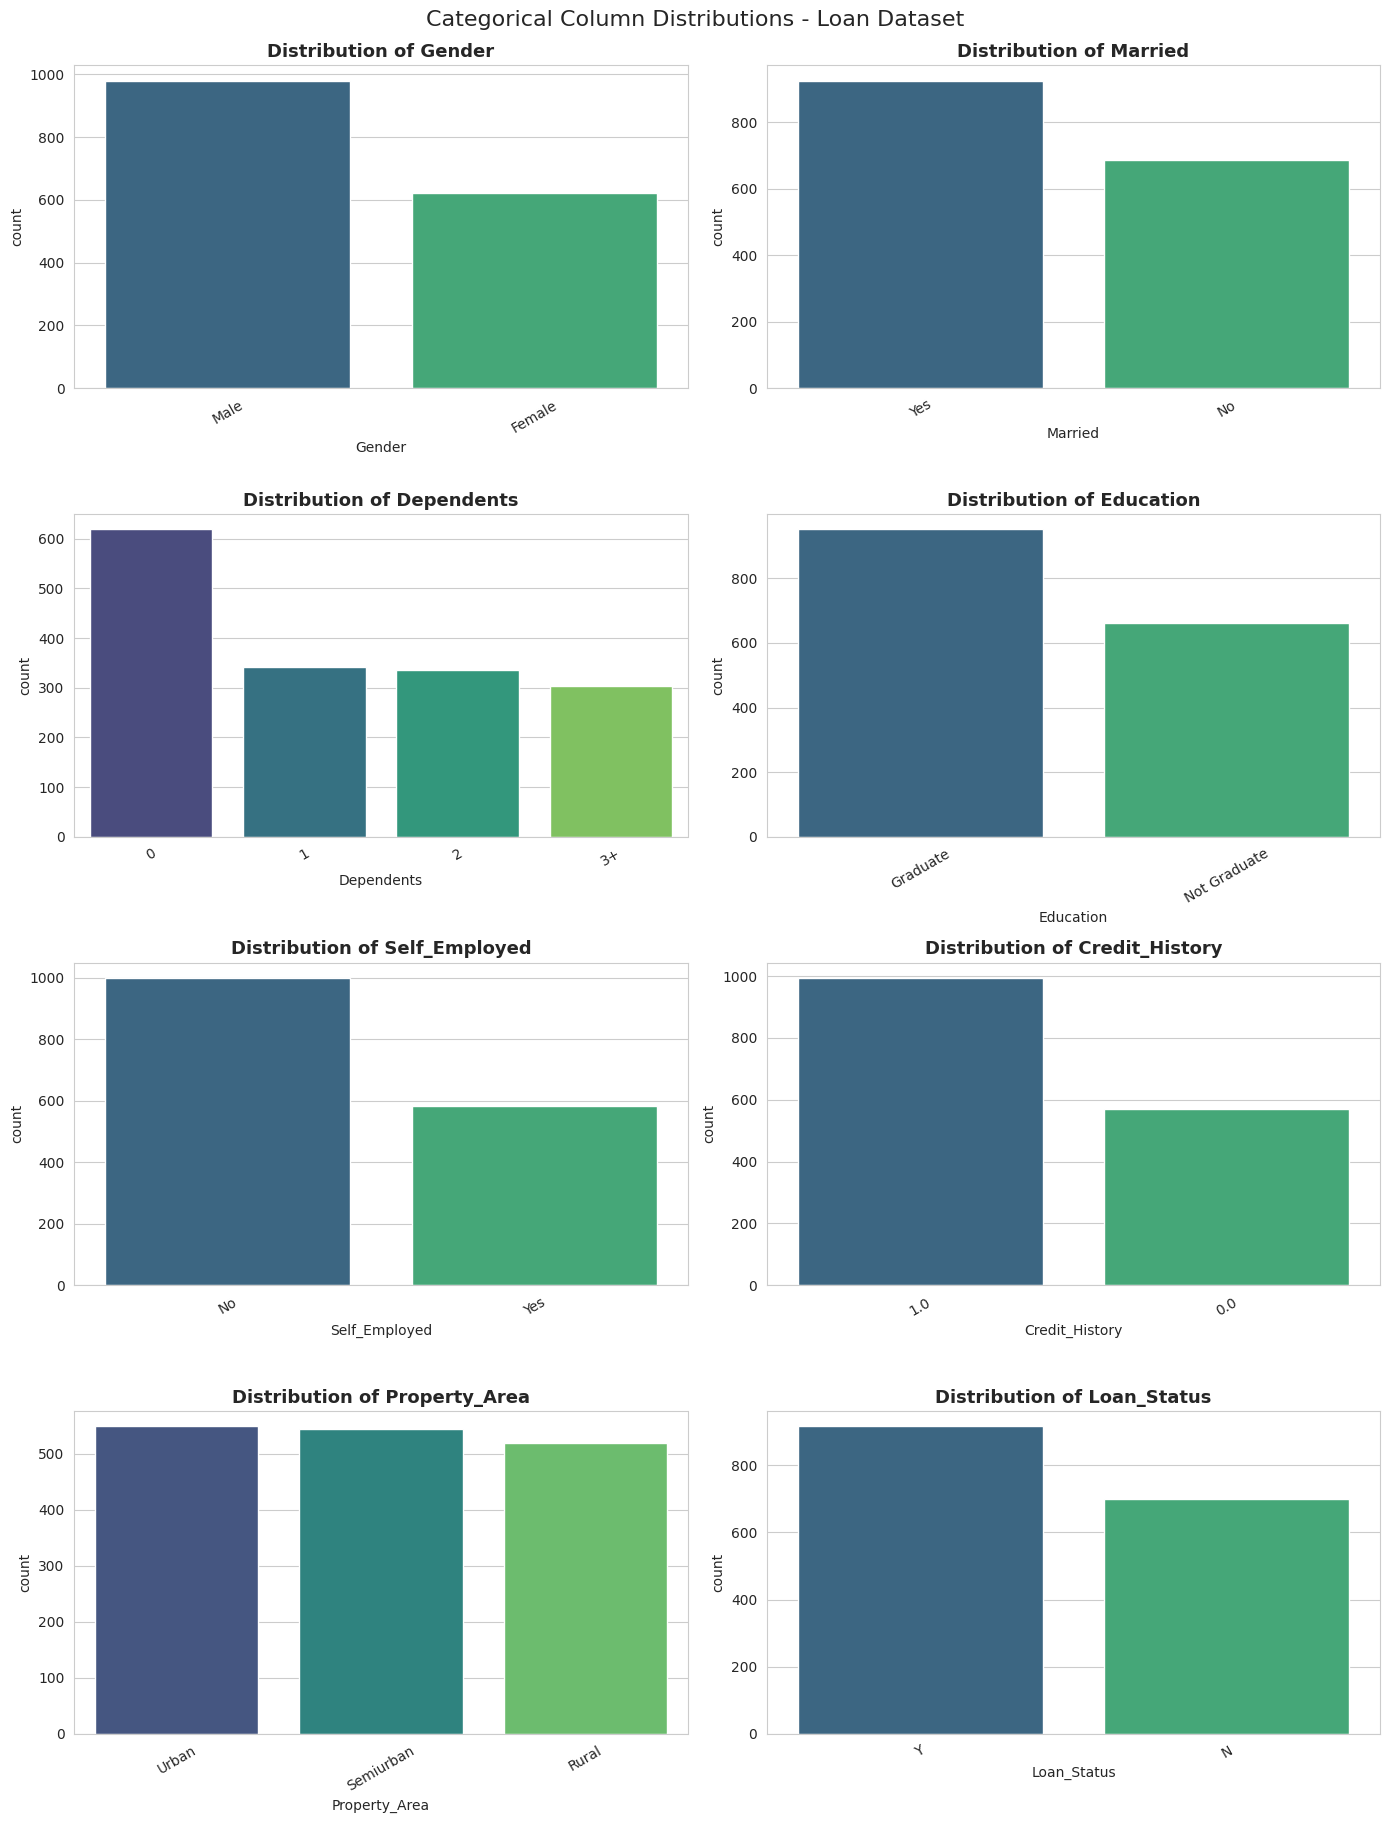

In [8]:
cat_cols_loan = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                  'Credit_History', 'Property_Area', 'Loan_Status']
num_cols_loan = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols_loan):
    order = loan[col].value_counts().index
    sns.countplot(x=col, data=loan, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.suptitle('Categorical Column Distributions - Loan Dataset', y=1.01, fontsize=16)
plt.show()


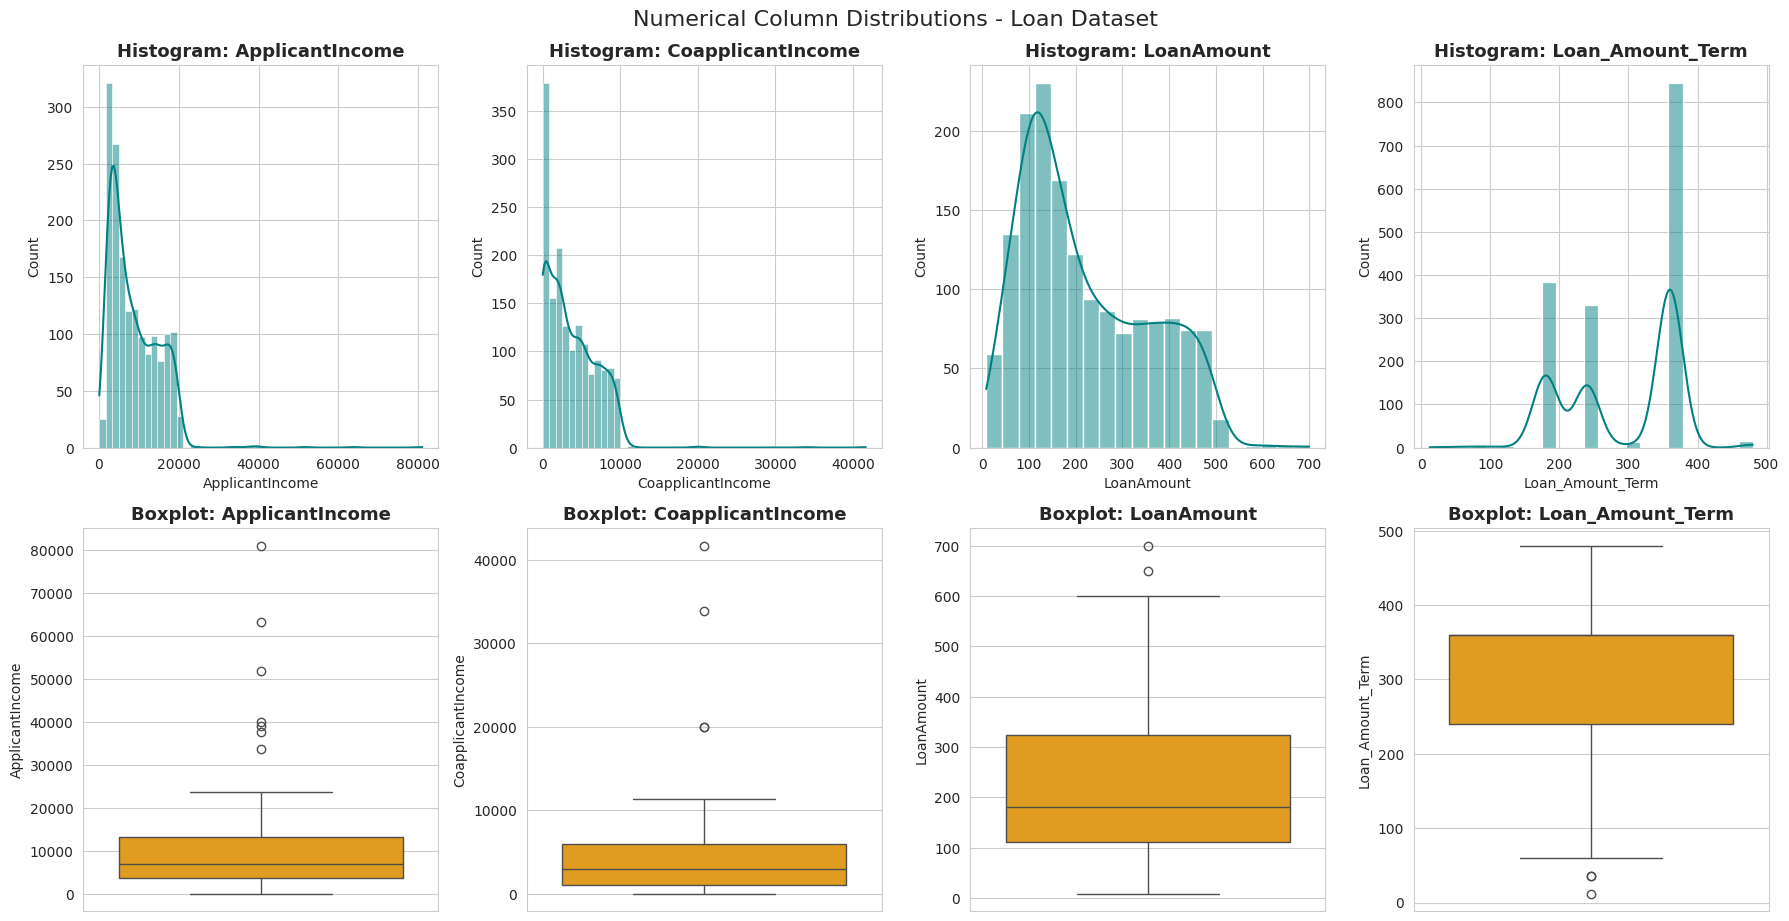

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, col in enumerate(num_cols_loan):
    sns.histplot(loan[col].dropna(), kde=True, ax=axes[0, i], color='teal')
    axes[0, i].set_title(f'Histogram: {col}')
    sns.boxplot(y=loan[col].dropna(), ax=axes[1, i], color='orange')
    axes[1, i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.suptitle('Numerical Column Distributions - Loan Dataset', y=1.02, fontsize=16)
plt.show()


## 1.5 Bivariate Analysis (Against `Loan_Status`)

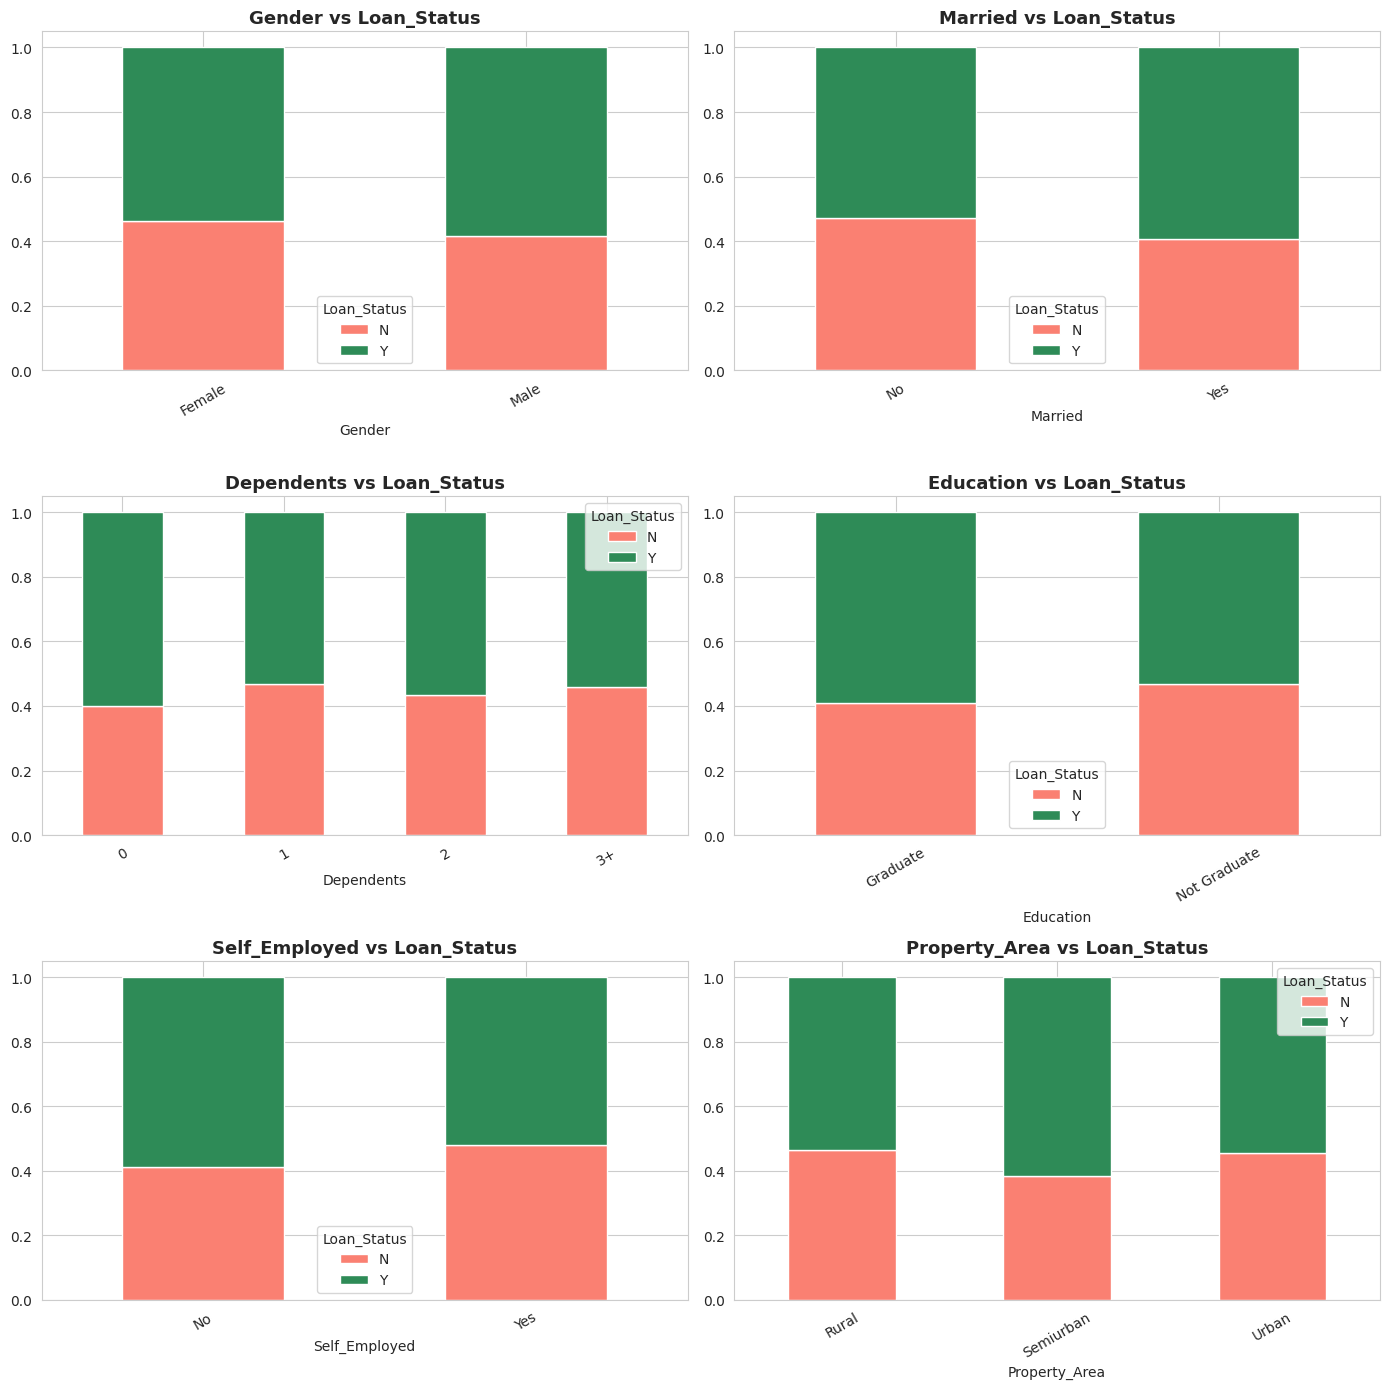

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']):
    ct = pd.crosstab(loan[col], loan['Loan_Status'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['salmon', 'seagreen'])
    axes[i].set_title(f'{col} vs Loan_Status')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Loan_Status')
plt.tight_layout()
plt.show()


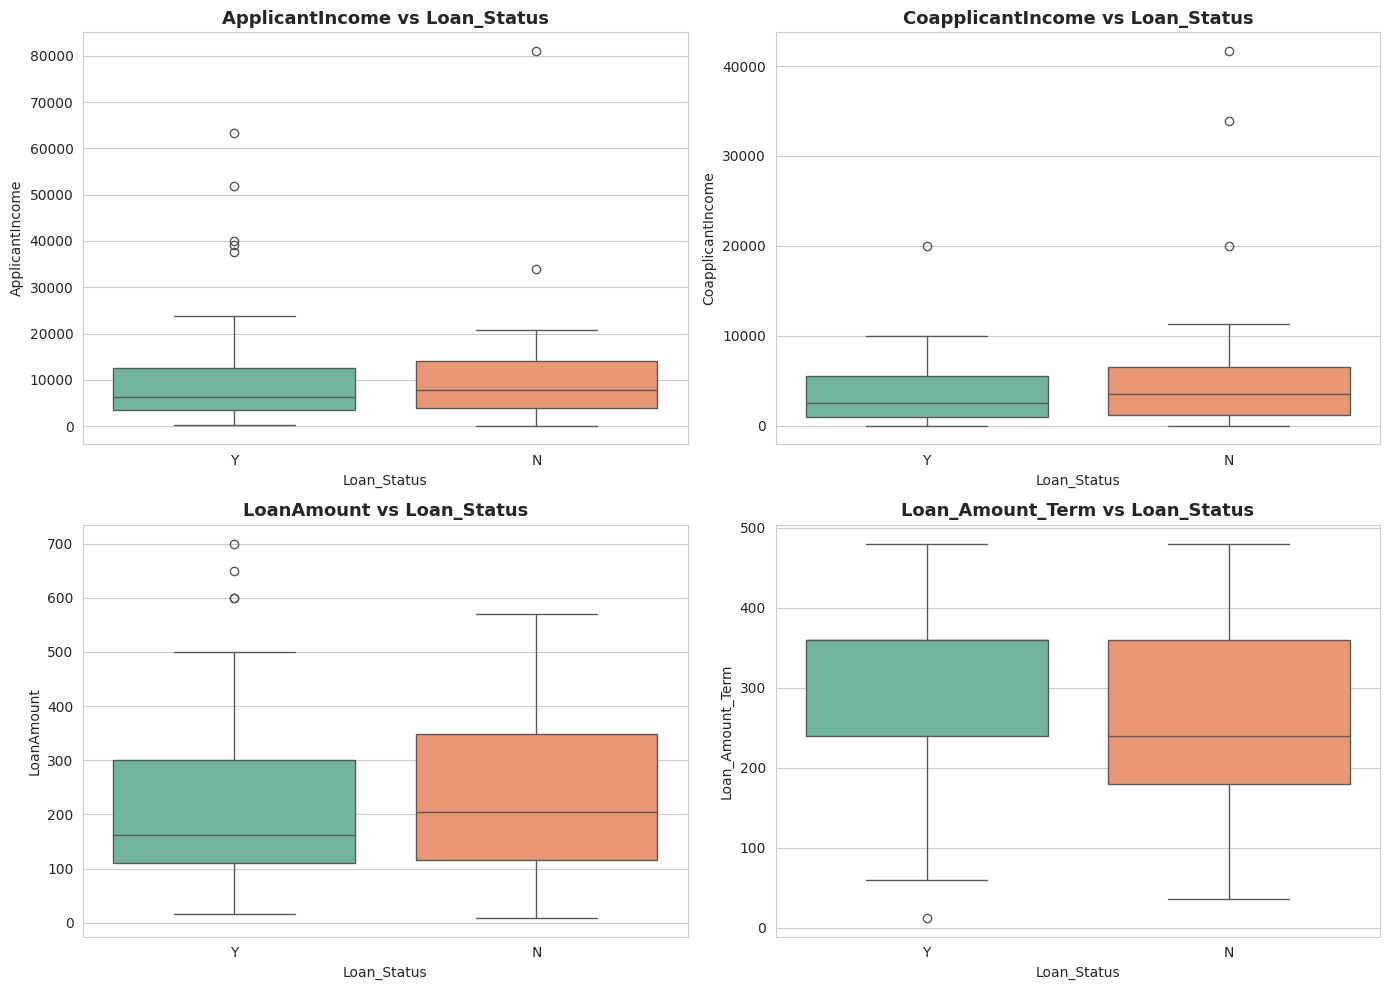

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols_loan):
    sns.boxplot(x='Loan_Status', y=col, data=loan, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Loan_Status')
plt.tight_layout()
plt.show()


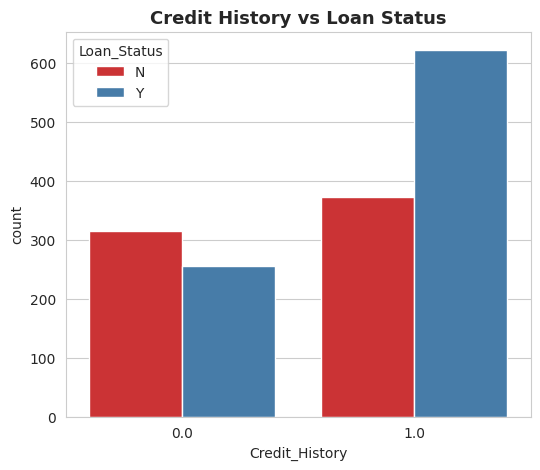

In [12]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan, palette='Set1')
plt.title('Credit History vs Loan Status')
plt.show()


## 1.6 Outlier Detection (IQR Method)

In [13]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print("Outlier summary (IQR method) - Loan Dataset")
for col in num_cols_loan:
    cnt, low, up = detect_outliers_iqr(loan, col)
    print(f"{col:20s} -> Outliers: {cnt:4d} | Valid range: [{low:.1f}, {up:.1f}]")


Outlier summary (IQR method) - Loan Dataset
ApplicantIncome      -> Outliers:    7 | Valid range: [-10688.4, 27614.6]
CoapplicantIncome    -> Outliers:    4 | Valid range: [-6373.9, 13253.1]
LoanAmount           -> Outliers:    2 | Valid range: [-206.0, 642.0]
Loan_Amount_Term     -> Outliers:    3 | Valid range: [60.0, 540.0]


## 1.7 Data Cleaning

Steps performed:
1. Impute missing categorical values with mode (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`)
2. Impute missing `LoanAmount` with median (robust to outliers)
3. Impute missing `Loan_Amount_Term` with mode (most common term)
4. Clean `Dependents` column (convert `3+` to `3` for numeric usability, keep a categorical copy)
5. Cap outliers in `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount` using IQR capping (winsorization) instead of dropping rows, to preserve data
6. Verify no duplicate rows


In [14]:
loan_clean = loan.copy()

# 1. Categorical imputation with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    loan_clean[col] = loan_clean[col].fillna(loan_clean[col].mode()[0])

# 2. LoanAmount -> median
loan_clean['LoanAmount'] = loan_clean['LoanAmount'].fillna(loan_clean['LoanAmount'].median())

# 3. Loan_Amount_Term -> mode
loan_clean['Loan_Amount_Term'] = loan_clean['Loan_Amount_Term'].fillna(loan_clean['Loan_Amount_Term'].mode()[0])

print("Missing values after cleaning:")
print(loan_clean.isnull().sum())


Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [15]:
# 4. Clean Dependents column
loan_clean['Dependents_numeric'] = loan_clean['Dependents'].replace('3+', '3').astype(int)
loan_clean[['Dependents', 'Dependents_numeric']].drop_duplicates()


,Dependents,Dependents_numeric
0,0,0
1,1,1
5,2,2
7,3+,3


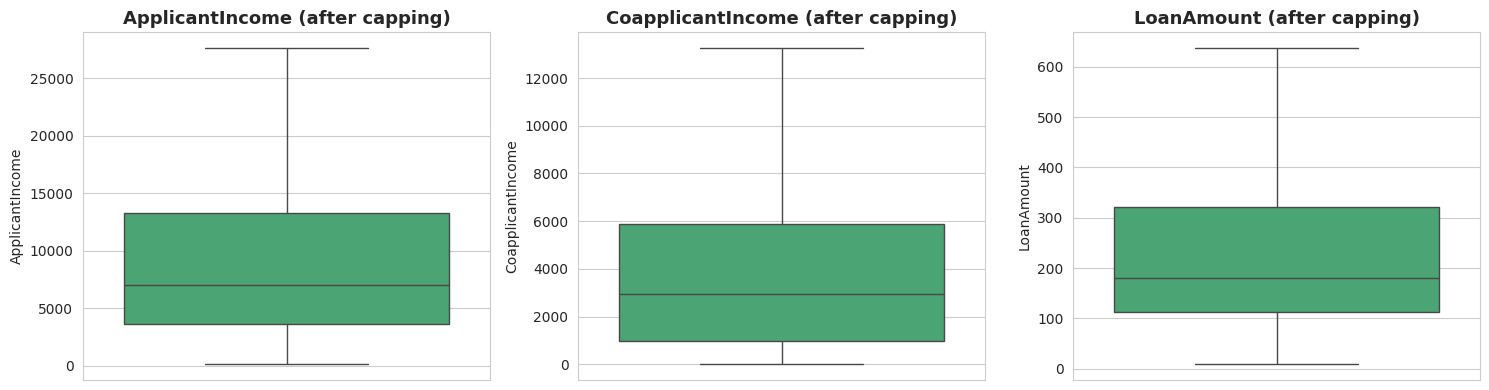

In [16]:
# 5. Outlier capping using IQR (winsorization)
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper, upper, np.where(df[col] < lower, lower, df[col]))
    return df

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    loan_clean = cap_outliers_iqr(loan_clean, col)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']):
    sns.boxplot(y=loan_clean[col], ax=axes[i], color='mediumseagreen')
    axes[i].set_title(f'{col} (after capping)')
plt.tight_layout()
plt.show()


In [17]:
# 6. Duplicate check
print("Duplicate rows after cleaning:", loan_clean.duplicated().sum())


Duplicate rows after cleaning: 0


## 1.8 Correlation Analysis

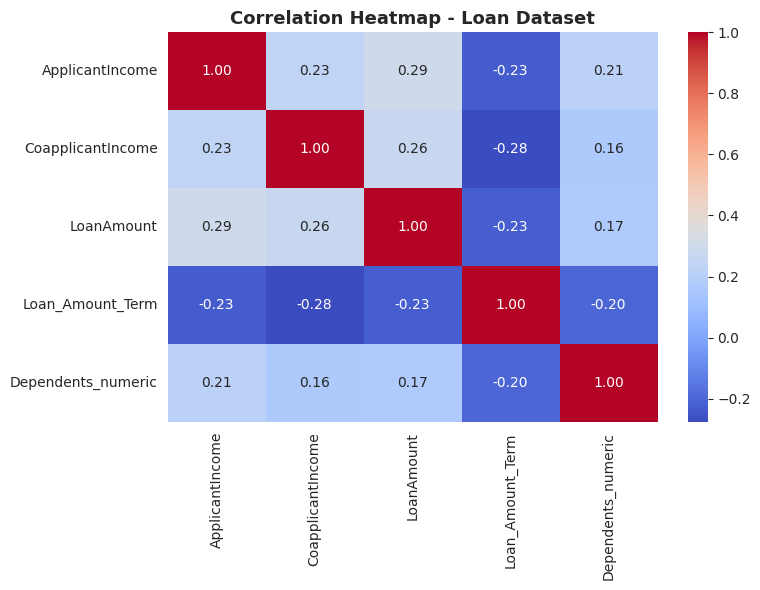

In [18]:
plt.figure(figsize=(8, 6))
corr_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Dependents_numeric']
sns.heatmap(loan_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Loan Dataset')
plt.tight_layout()
plt.show()


In [19]:
print("Final cleaned Loan dataset shape:", loan_clean.shape)
loan_clean.head()


Final cleaned Loan dataset shape: (1614, 14)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Dependents_numeric
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,180.0,360.0,1.0,Urban,Y,0
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y,0
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y,0


---
# Dataset 2: Adult Census Income Dataset
---
This dataset contains US census records used to predict whether income exceeds $50K/year (`income`).


## 2.1 Load Data & Initial Inspection

In [20]:
adult = pd.read_csv('adult__1_.csv')
print("Shape:", adult.shape)
adult.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [21]:
adult.info()


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [22]:
adult.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,48842,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educational-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,48842,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Missing Value Analysis

This dataset has **no NaN values reported by pandas**, but missing data is encoded as `'?'` in several categorical columns (`workclass`, `occupation`, `native-country`). We treat these as missing.


In [23]:
print("Standard NaN check:")
print(adult.isnull().sum().sum(), "total NaNs\n")

print("'?' counts per column:")
q_counts = (adult == '?').sum()
q_counts = q_counts[q_counts > 0]
print(q_counts)


Standard NaN check:
0 total NaNs

'?' counts per column:
workclass         2799
occupation        2809
native-country     857
dtype: int64


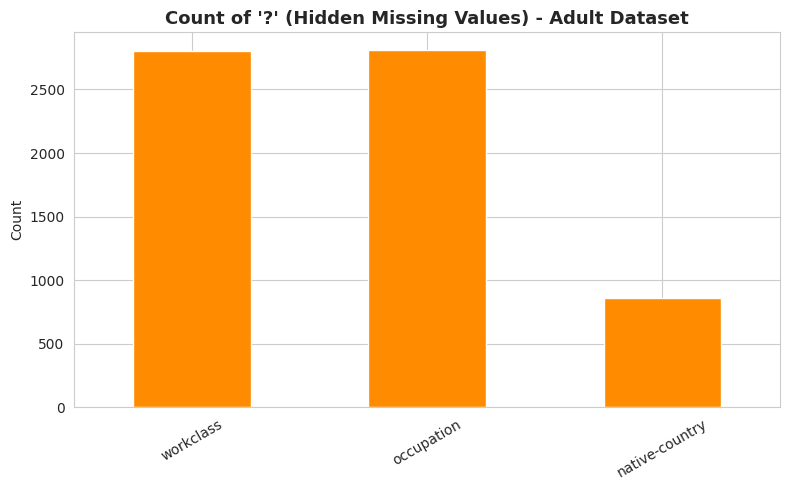

In [24]:
plt.figure(figsize=(8, 5))
q_counts.plot(kind='bar', color='darkorange')
plt.title("Count of '?' (Hidden Missing Values) - Adult Dataset")
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 2.3 Duplicate Check

In [25]:
print("Duplicate rows in Adult dataset:", adult.duplicated().sum())


Duplicate rows in Adult dataset: 52


## 2.4 Univariate Analysis (Every Column)

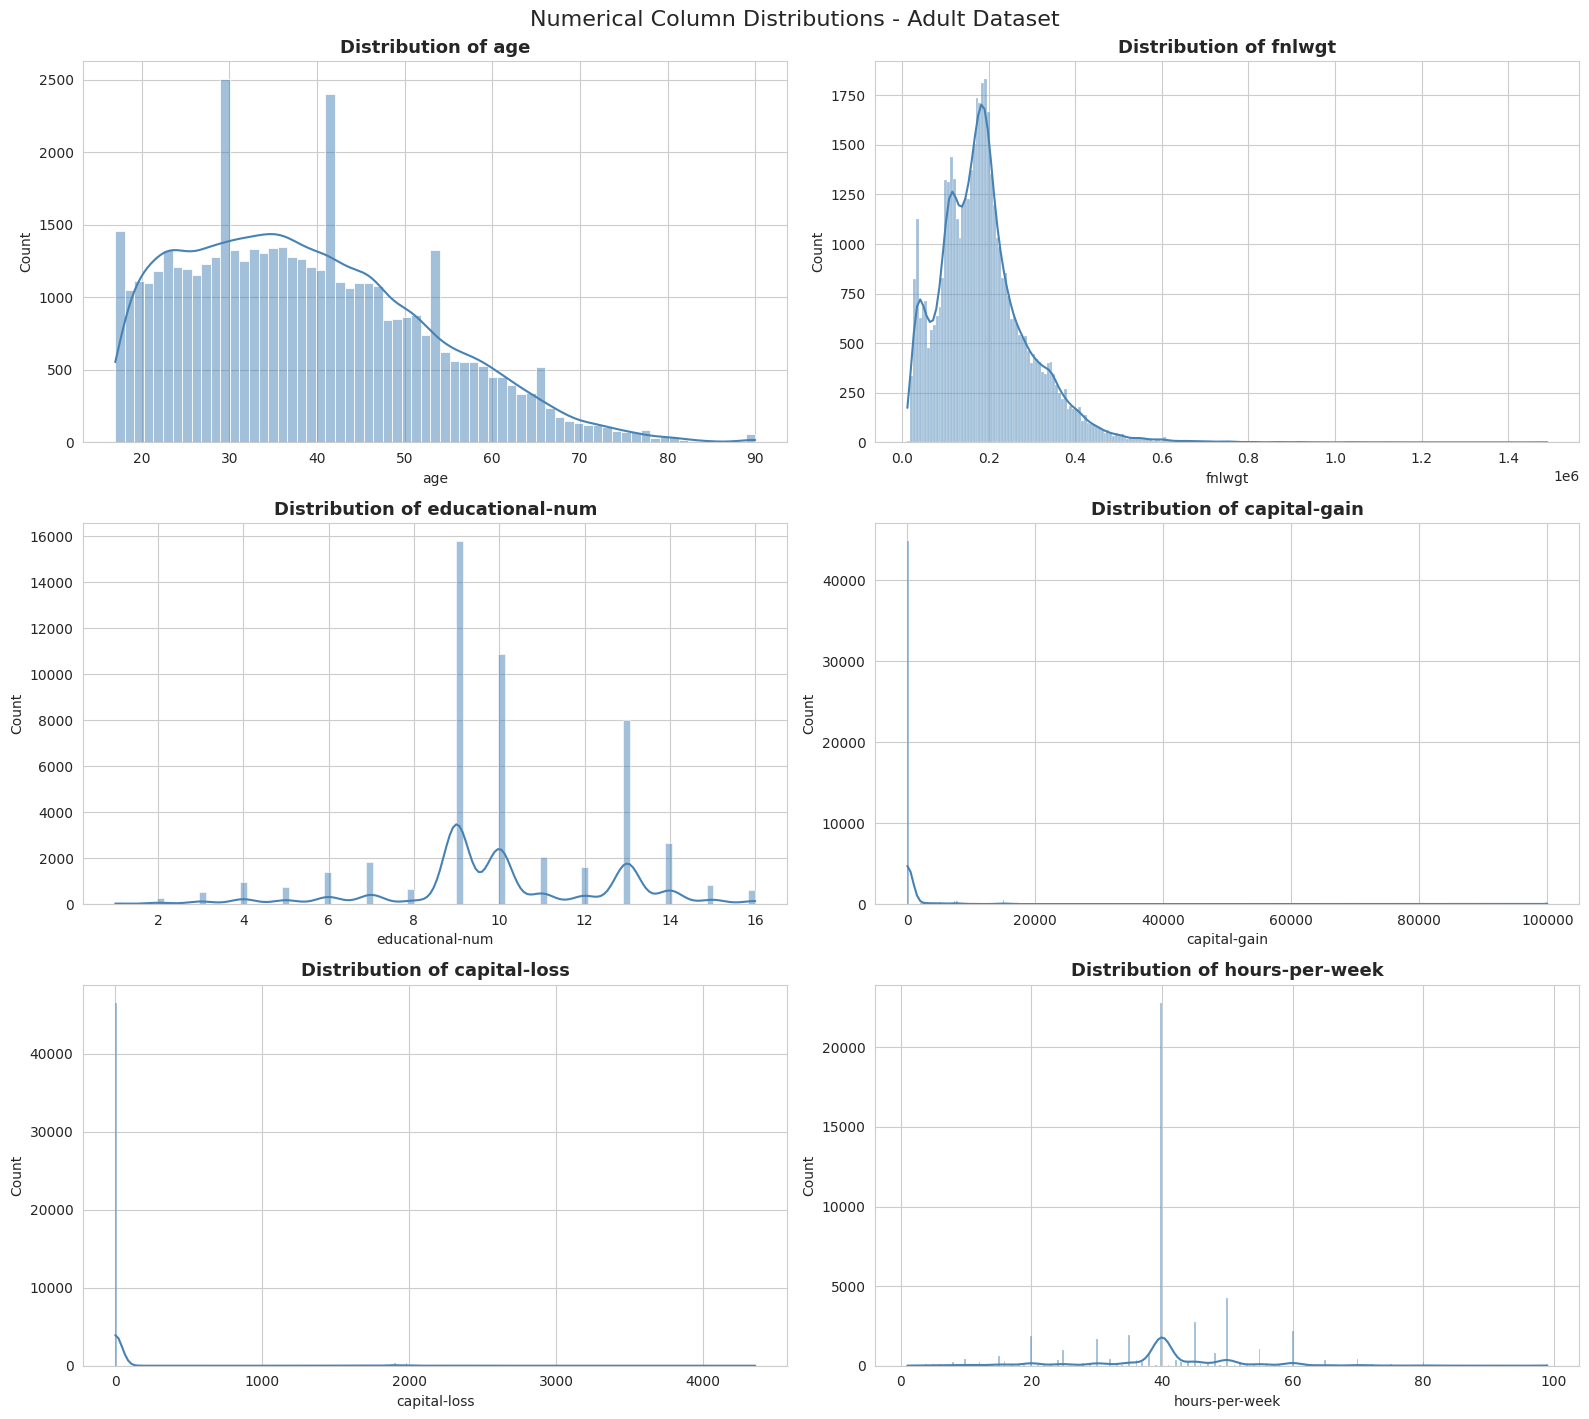

In [26]:
num_cols_adult = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols_adult = ['workclass', 'education', 'marital-status', 'occupation', 'relationship',
                   'race', 'gender', 'native-country', 'income']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols_adult):
    sns.histplot(adult[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.suptitle('Numerical Column Distributions - Adult Dataset', y=1.01, fontsize=16)
plt.show()


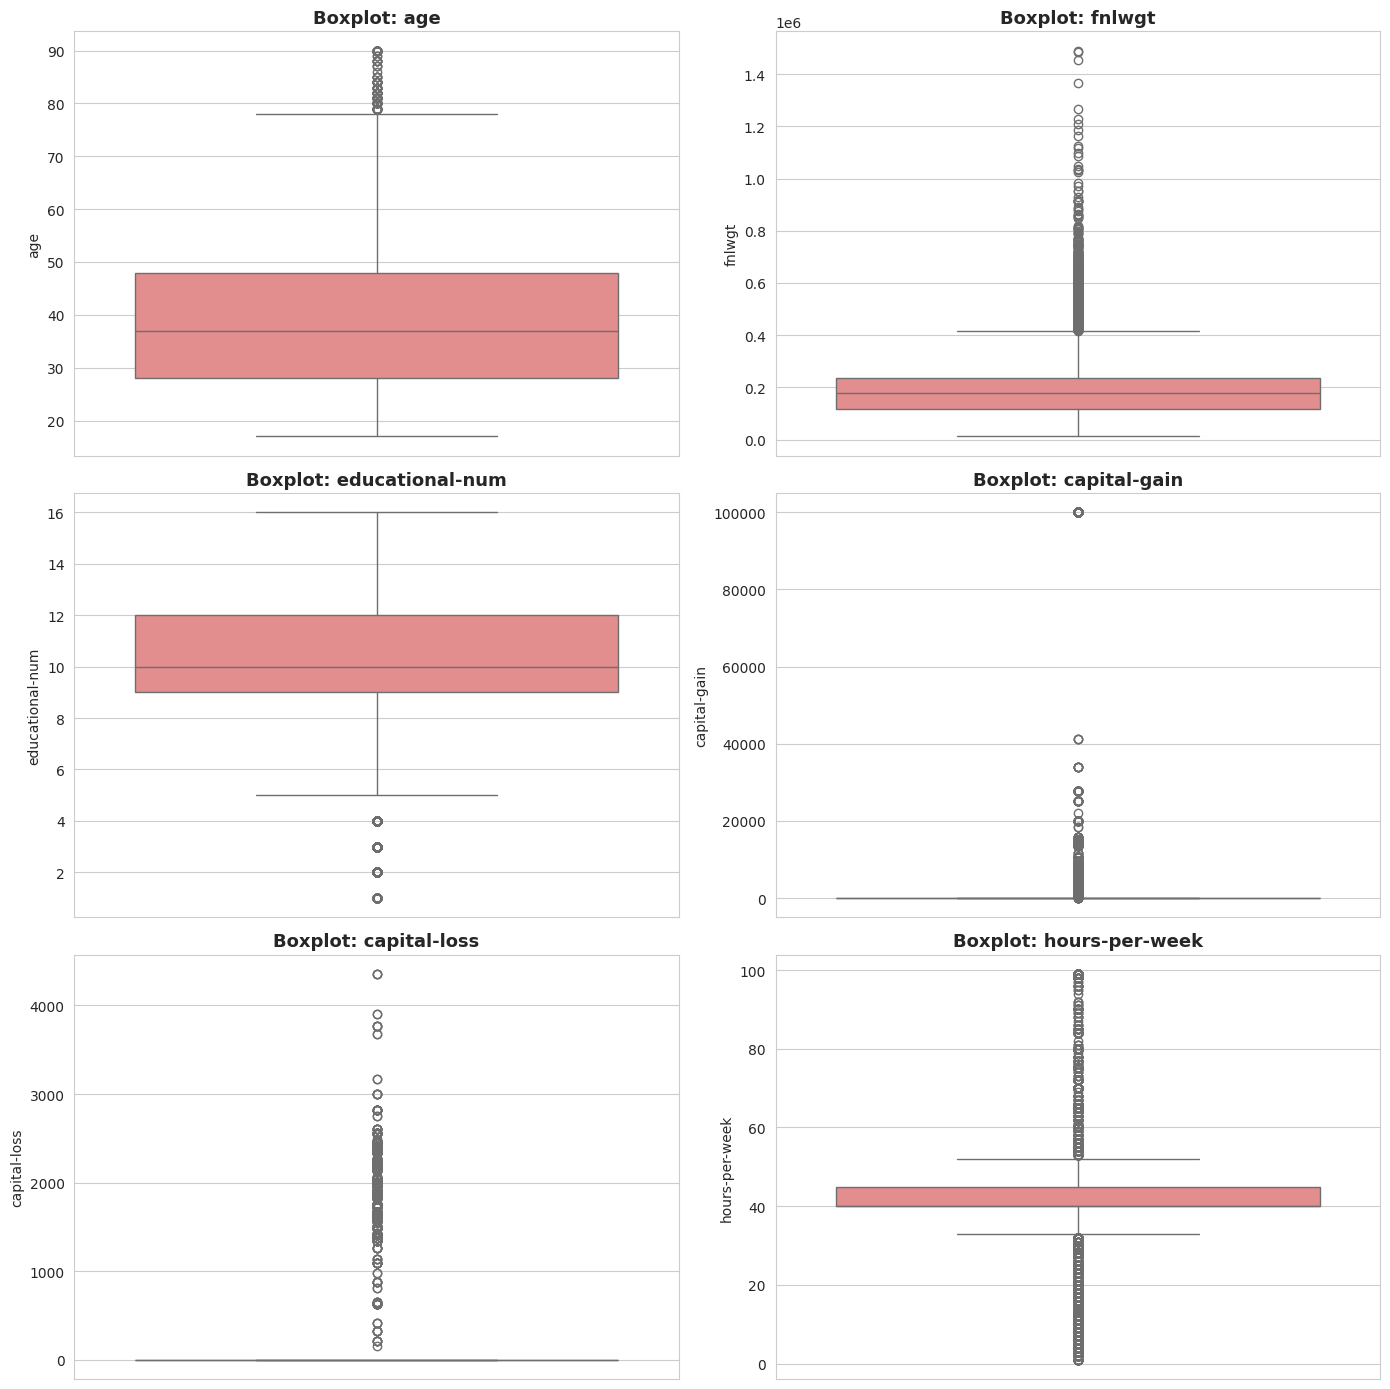

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for i, col in enumerate(num_cols_adult):
    ax = axes.flatten()[i]
    sns.boxplot(y=adult[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


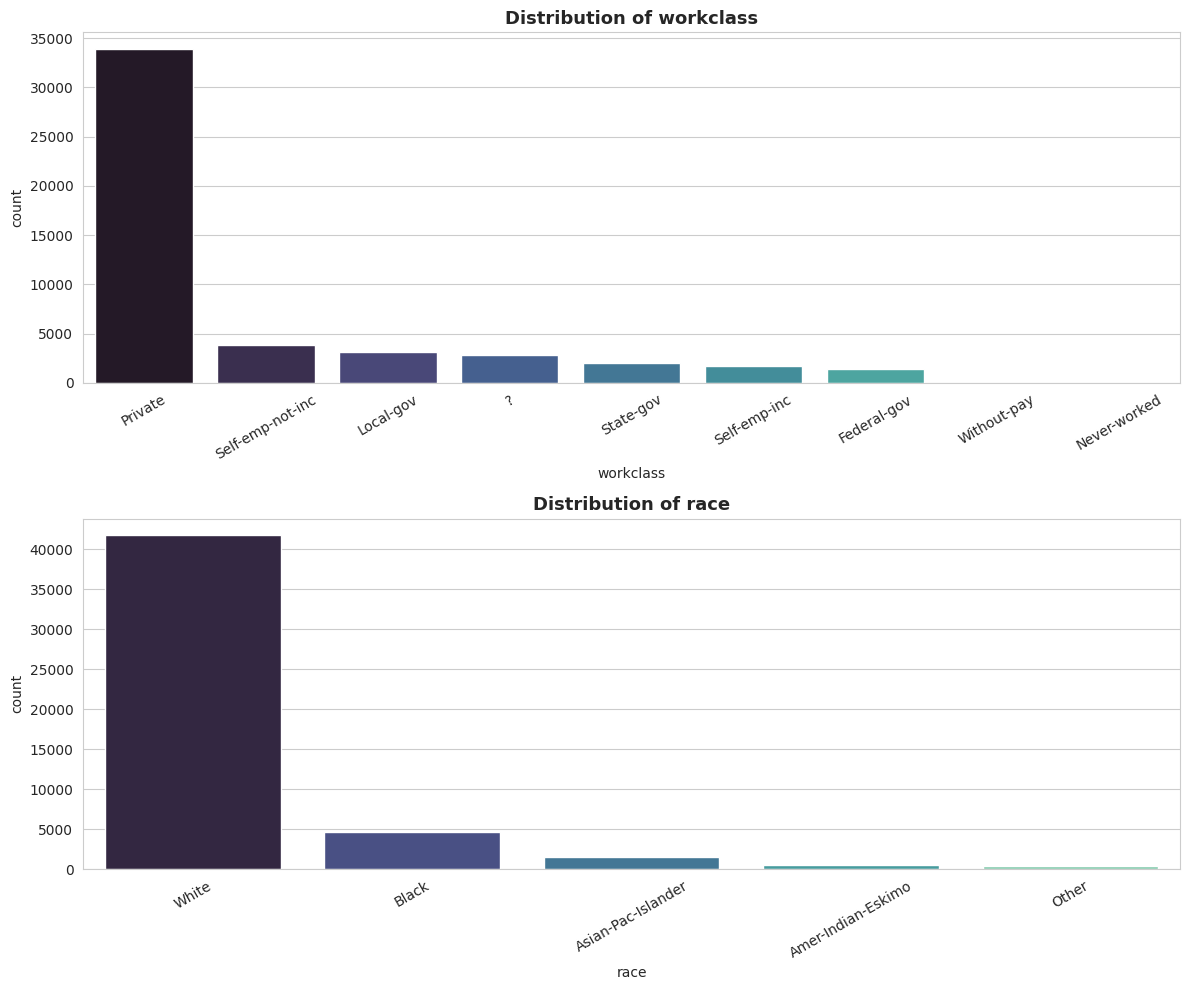

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, col in enumerate(['workclass', 'race']):
    order = adult[col].value_counts().index
    sns.countplot(x=col, data=adult, order=order, ax=axes[i], palette='mako')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


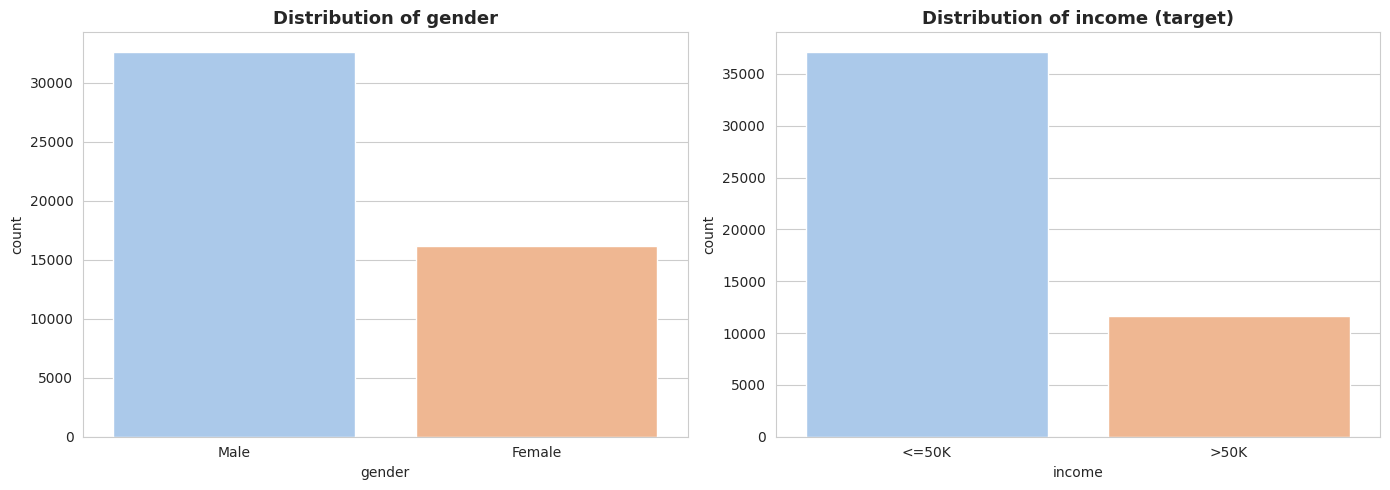

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='gender', data=adult, ax=axes[0], palette='pastel')
axes[0].set_title('Distribution of gender')
sns.countplot(x='income', data=adult, ax=axes[1], palette='pastel')
axes[1].set_title('Distribution of income (target)')
plt.tight_layout()
plt.show()


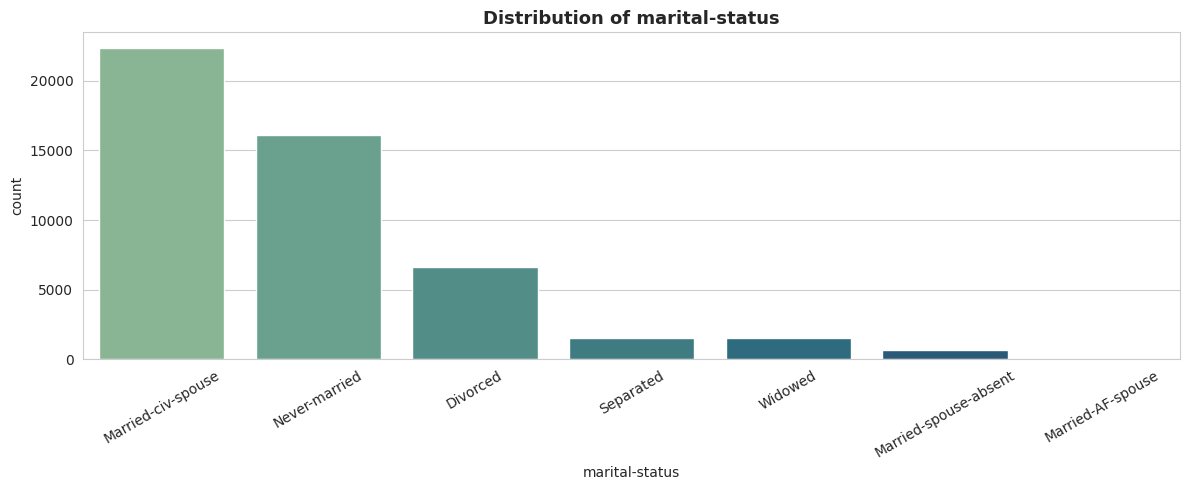

In [30]:
plt.figure(figsize=(12, 5))
order = adult['marital-status'].value_counts().index
sns.countplot(x='marital-status', data=adult, order=order, palette='crest')
plt.title('Distribution of marital-status')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


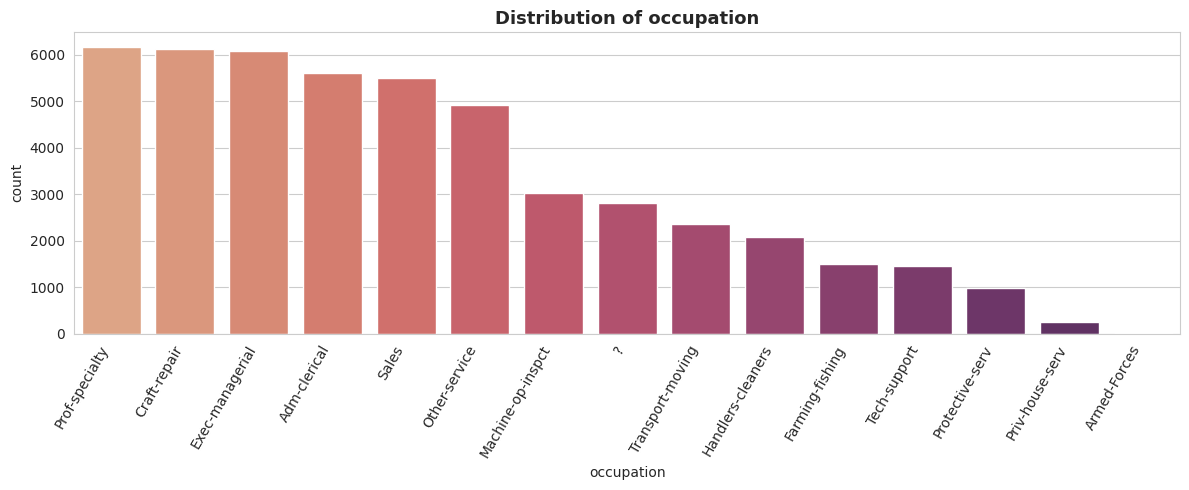

In [31]:
plt.figure(figsize=(12, 5))
order = adult['occupation'].value_counts().index
sns.countplot(x='occupation', data=adult, order=order, palette='flare')
plt.title('Distribution of occupation')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


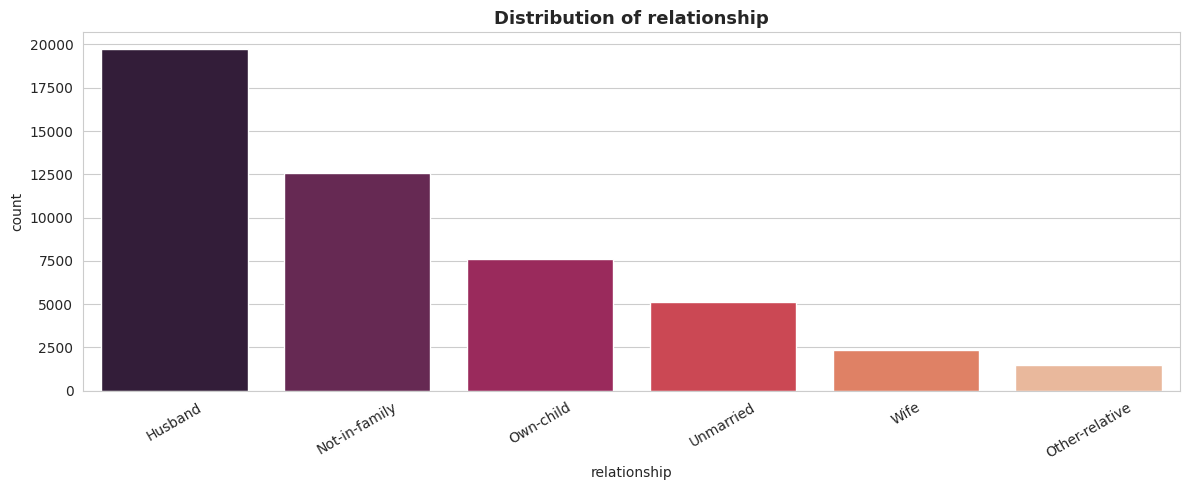

In [32]:
plt.figure(figsize=(12, 5))
order = adult['relationship'].value_counts().index
sns.countplot(x='relationship', data=adult, order=order, palette='rocket')
plt.title('Distribution of relationship')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


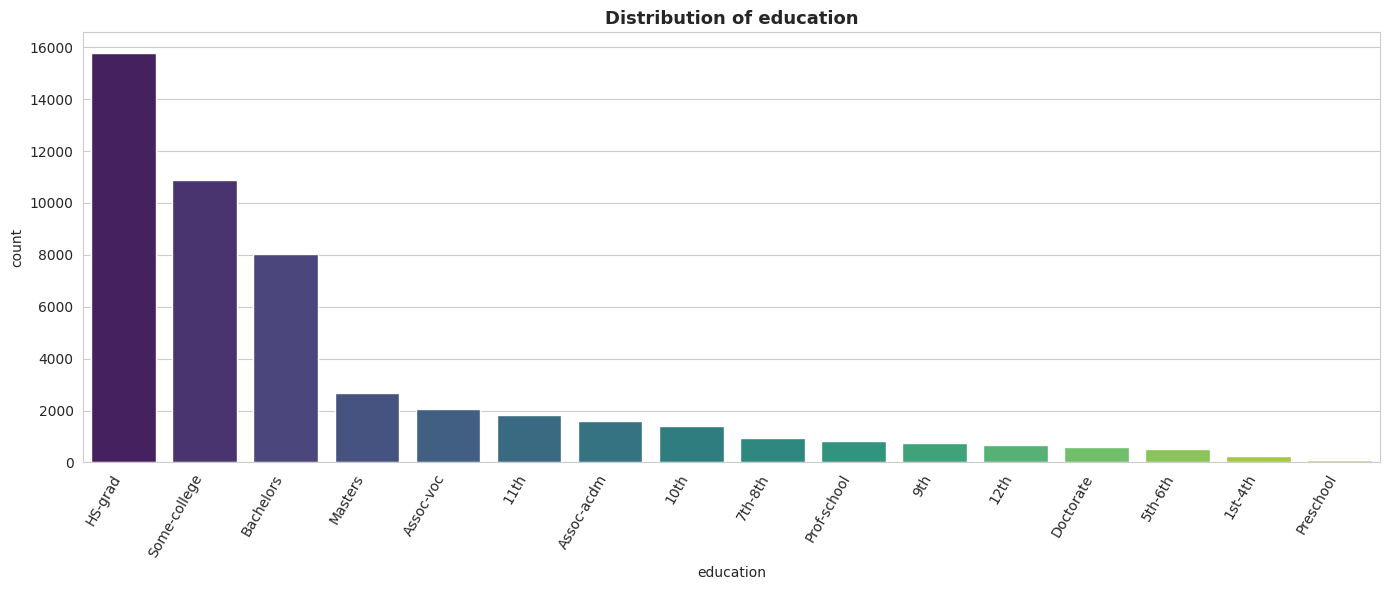

In [33]:
plt.figure(figsize=(14, 6))
order = adult['education'].value_counts().index
sns.countplot(x='education', data=adult, order=order, palette='viridis')
plt.title('Distribution of education')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


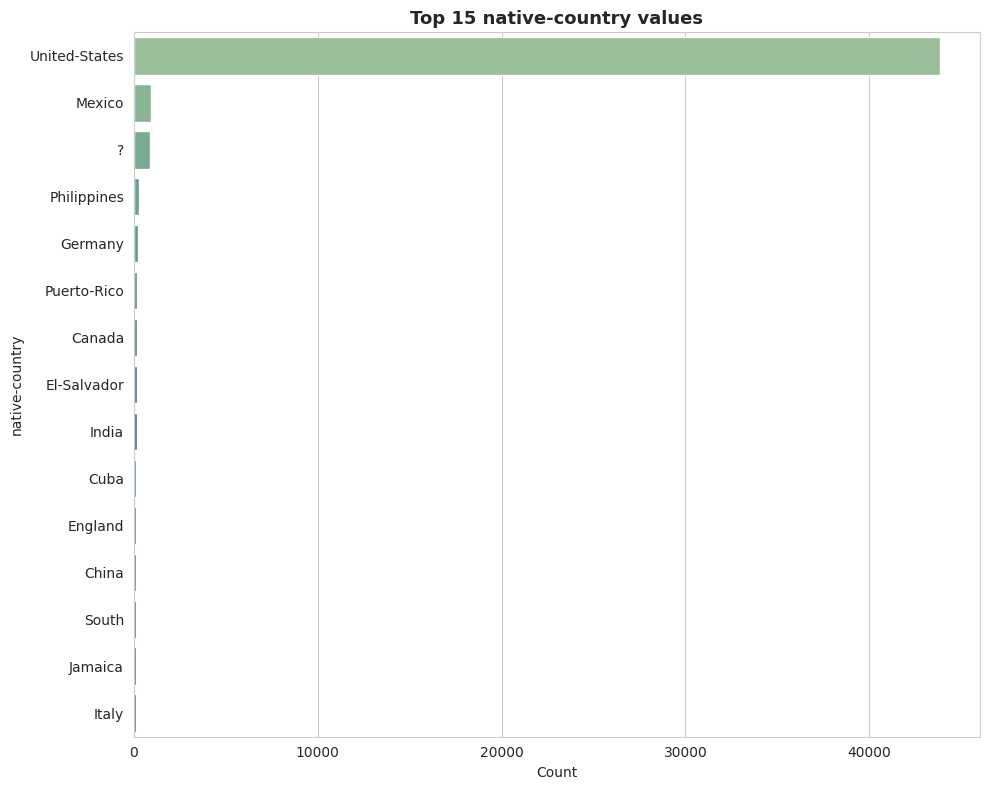

In [34]:
plt.figure(figsize=(10, 8))
top_countries = adult['native-country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title('Top 15 native-country values')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


## 2.5 Bivariate Analysis (Against `income`)

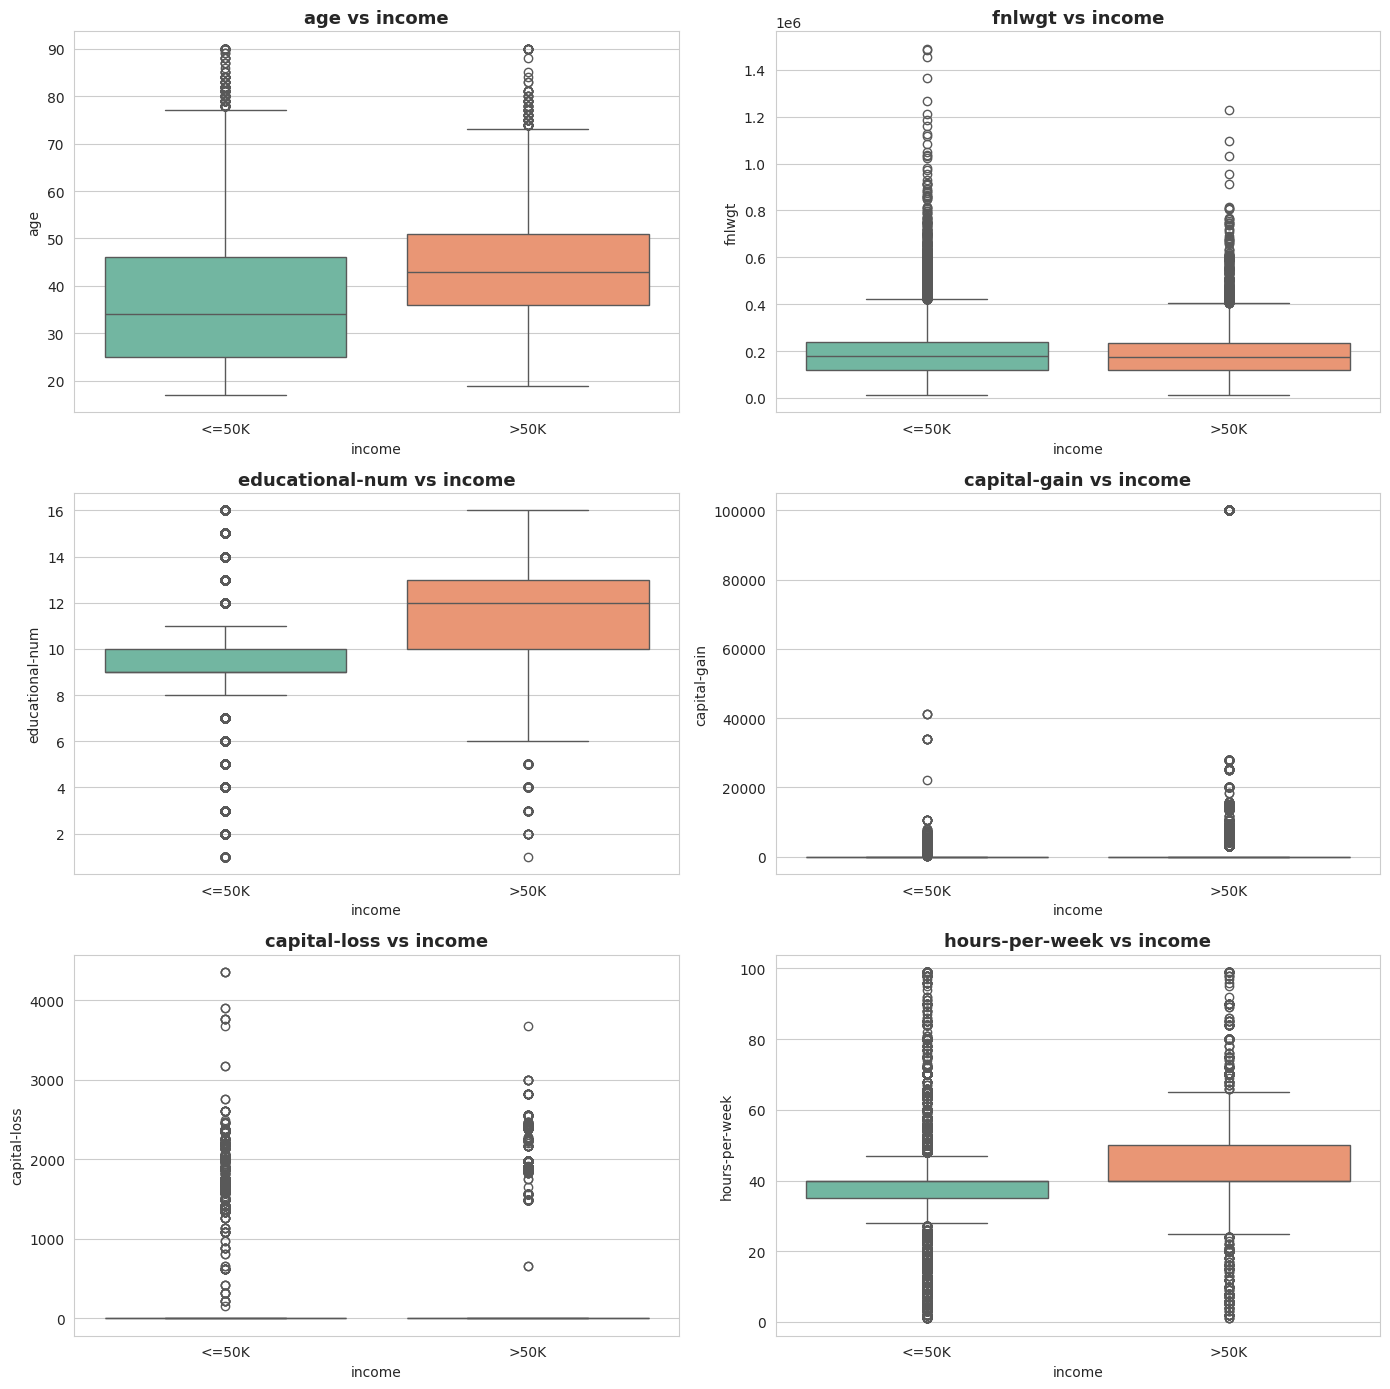

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols_adult):
    sns.boxplot(x='income', y=col, data=adult, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs income')
plt.tight_layout()
plt.show()


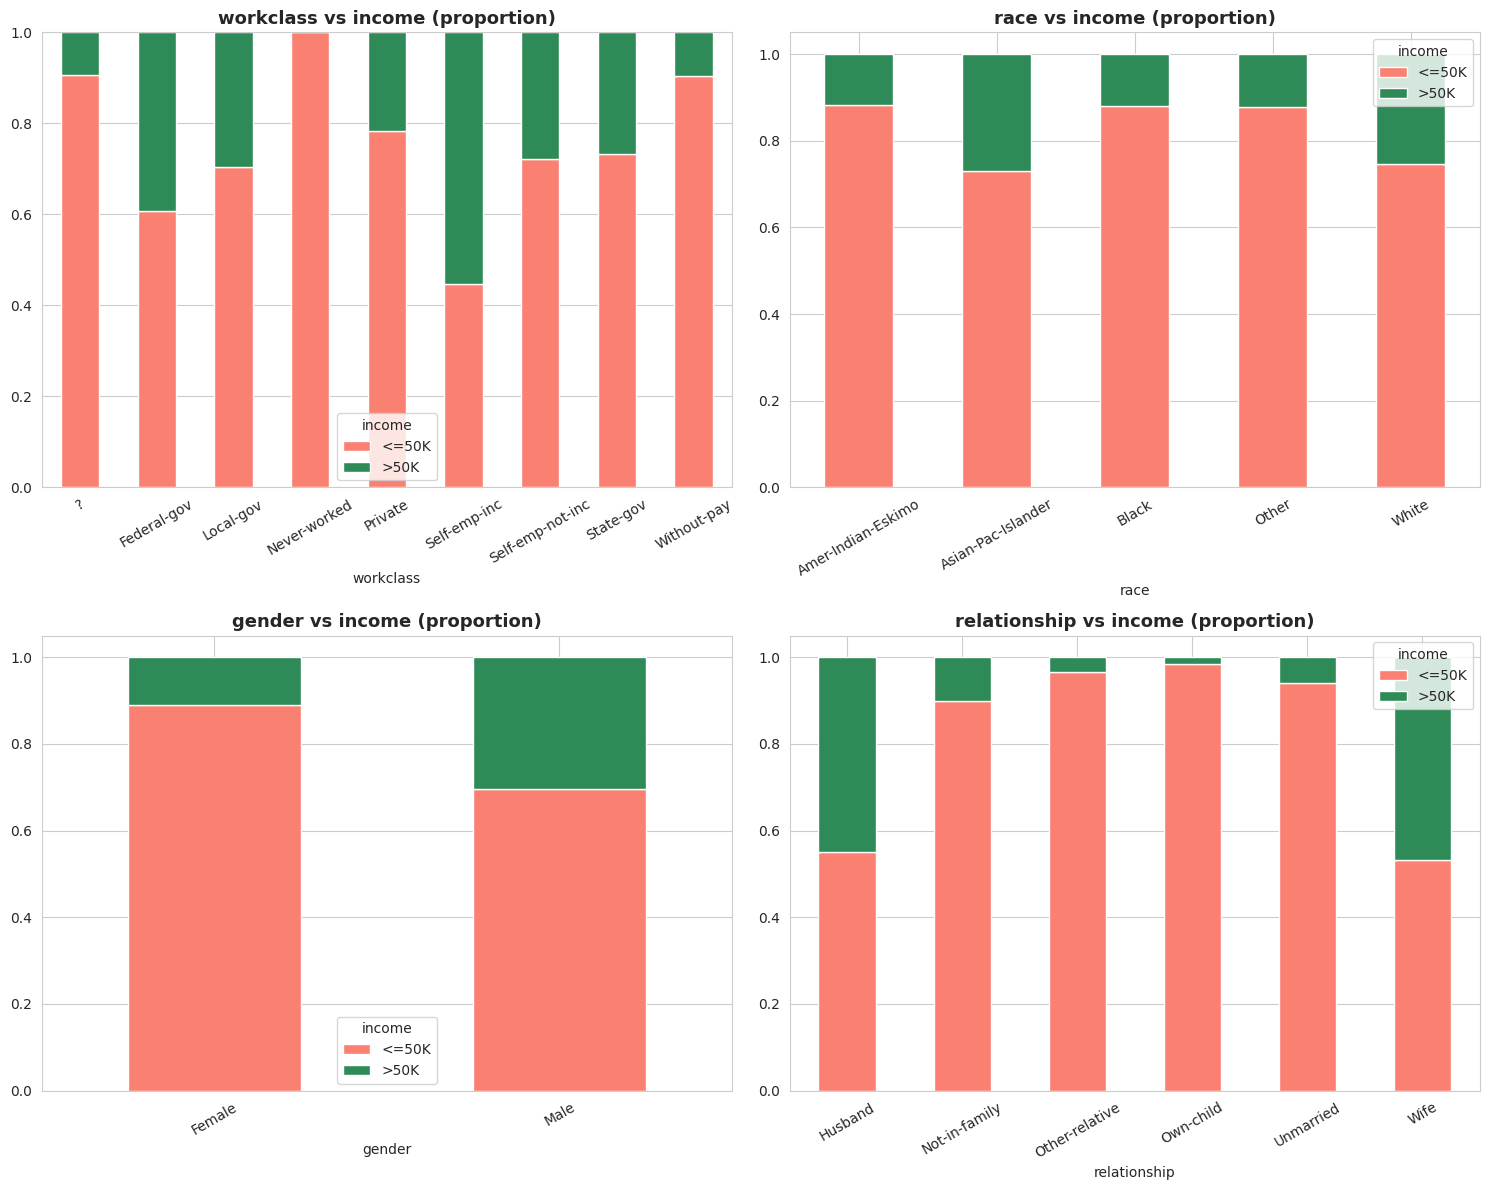

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(['workclass', 'race', 'gender', 'relationship']):
    ct = pd.crosstab(adult[col], adult['income'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['salmon', 'seagreen'])
    axes[i].set_title(f'{col} vs income (proportion)')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 2.6 Outlier Detection (IQR Method)

In [37]:
print("Outlier summary (IQR method) - Adult Dataset")
for col in num_cols_adult:
    cnt, low, up = detect_outliers_iqr(adult, col)
    print(f"{col:20s} -> Outliers: {cnt:6d} | Valid range: [{low:.1f}, {up:.1f}]")


Outlier summary (IQR method) - Adult Dataset
age                  -> Outliers:    216 | Valid range: [-2.0, 78.0]
fnlwgt               -> Outliers:   1453 | Valid range: [-62586.8, 417779.2]
educational-num      -> Outliers:   1794 | Valid range: [4.5, 16.5]
capital-gain         -> Outliers:   4035 | Valid range: [0.0, 0.0]
capital-loss         -> Outliers:   2282 | Valid range: [0.0, 0.0]
hours-per-week       -> Outliers:  13496 | Valid range: [32.5, 52.5]


## 2.7 Data Cleaning

Steps performed:
1. Replace `'?'` with NaN, then impute with mode for `workclass`, `occupation`, `native-country`
2. Remove duplicate rows
3. `capital-gain`/`capital-loss` are heavily zero-inflated (legitimate business behavior, not true outliers) — we leave them untouched but flag extreme `age`/`hours-per-week` values by capping with IQR
4. Standardize text columns (strip whitespace)
5. Verify final missing values and duplicates are zero


In [38]:
adult_clean = adult.copy()

# 1. Replace '?' with NaN then impute with mode
for col in ['workclass', 'occupation', 'native-country']:
    adult_clean[col] = adult_clean[col].replace('?', np.nan)
    adult_clean[col] = adult_clean[col].fillna(adult_clean[col].mode()[0])

print("Remaining '?' values:", (adult_clean == '?').sum().sum())


Remaining '?' values: 0


In [39]:
# 2. Remove duplicates
before = adult_clean.shape[0]
adult_clean = adult_clean.drop_duplicates()
after = adult_clean.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {adult_clean.shape}")


Removed 53 duplicate rows. New shape: (48789, 15)


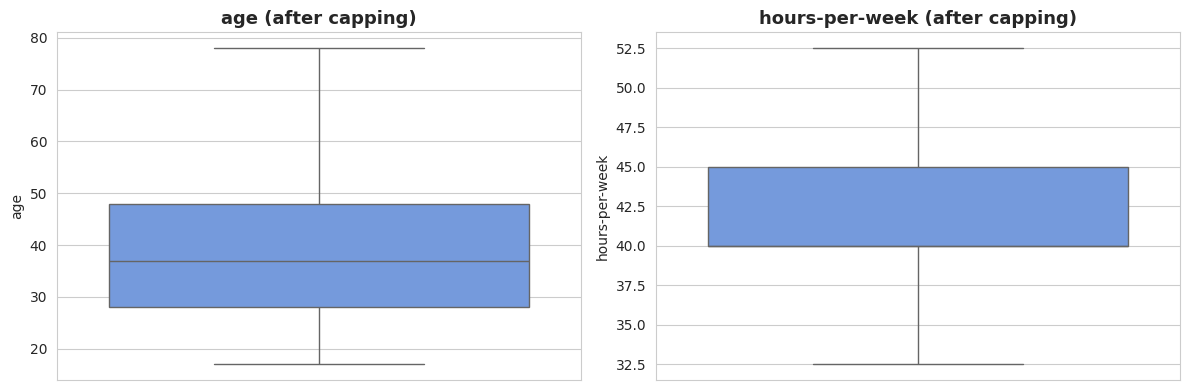

In [40]:
# 3. Cap extreme outliers in age & hours-per-week only (capital-gain/loss & fnlwgt kept as-is: legitimate skew)
for col in ['age', 'hours-per-week']:
    adult_clean = cap_outliers_iqr(adult_clean, col)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=adult_clean['age'], ax=axes[0], color='cornflowerblue')
axes[0].set_title('age (after capping)')
sns.boxplot(y=adult_clean['hours-per-week'], ax=axes[1], color='cornflowerblue')
axes[1].set_title('hours-per-week (after capping)')
plt.tight_layout()
plt.show()


In [41]:
# 4. Standardize text columns
str_cols = adult_clean.select_dtypes(include='object').columns
for col in str_cols:
    adult_clean[col] = adult_clean[col].str.strip()

# 5. Final check
print("Final missing values:", adult_clean.isnull().sum().sum())
print("Final duplicate rows:", adult_clean.duplicated().sum())
print("Final shape:", adult_clean.shape)


Final missing values: 0
Final duplicate rows: 21
Final shape: (48789, 15)


## 2.8 Correlation Analysis

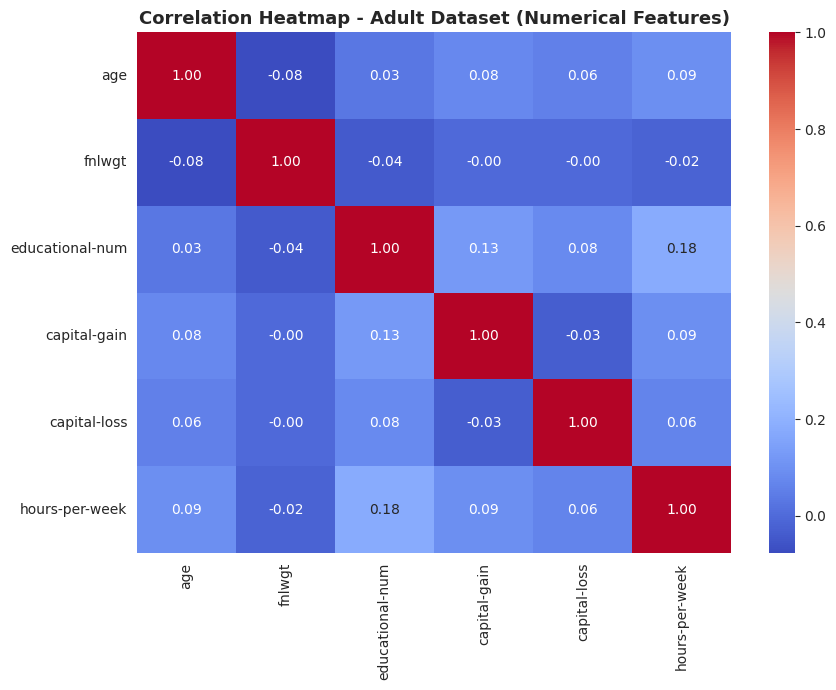

In [42]:
plt.figure(figsize=(9, 7))
sns.heatmap(adult_clean[num_cols_adult].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Adult Dataset (Numerical Features)')
plt.tight_layout()
plt.show()


In [43]:
adult_clean.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40.0,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50.0,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40.0,United-States,>50K
4,18.0,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,32.5,United-States,<=50K


---
# Dataset 3: Hotel Booking Dataset
---
This dataset contains hotel booking records, including whether the booking was cancelled (`is_canceled`).


## 3.1 Load Data & Initial Inspection

In [44]:
hotel = pd.read_csv('hotel_booking__1_.csv')
print("Shape:", hotel.shape)
hotel.head()


Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [45]:
hotel.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [46]:
hotel.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## 3.2 Missing Value Analysis

In [47]:
missing_hotel = hotel.isnull().sum()
missing_pct_hotel = (missing_hotel / len(hotel)) * 100
missing_df_hotel = pd.DataFrame({'Missing_Count': missing_hotel, 'Missing_%': missing_pct_hotel.round(2)})
missing_df_hotel = missing_df_hotel[missing_df_hotel['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_df_hotel


,Missing_Count,Missing_%
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


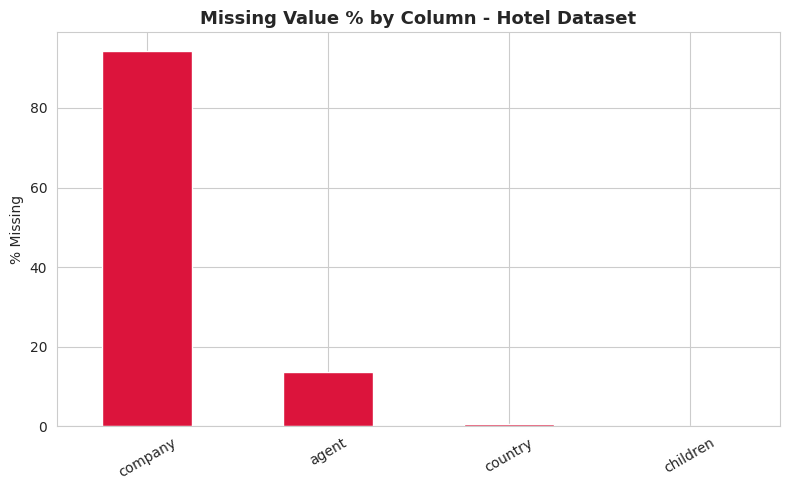

In [48]:
plt.figure(figsize=(8, 5))
missing_df_hotel['Missing_%'].plot(kind='bar', color='crimson')
plt.title('Missing Value % by Column - Hotel Dataset')
plt.ylabel('% Missing')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3.3 Duplicate Check

In [49]:
print("Duplicate rows in Hotel dataset:", hotel.duplicated().sum())


Duplicate rows in Hotel dataset: 0


## 3.4 Univariate Analysis (Every Column)

Given the large number of columns (36), we group and visualize them systematically: booking meta info, stay details, guest details, and financial/status details. Identifier-like columns (`name`, `email`, `phone-number`, `credit_card`) are inspected but not plotted (they carry no distributional meaning and are personally identifiable — handled in cleaning).


In [50]:
print("PII-style columns preview (will be dropped during cleaning):")
hotel[['name', 'email', 'phone-number', 'credit_card']].head()


PII-style columns preview (will be dropped during cleaning):


,name,email,phone-number,credit_card
0,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Linda Hines,LHines@verizon.com,713-226-5883,************5498


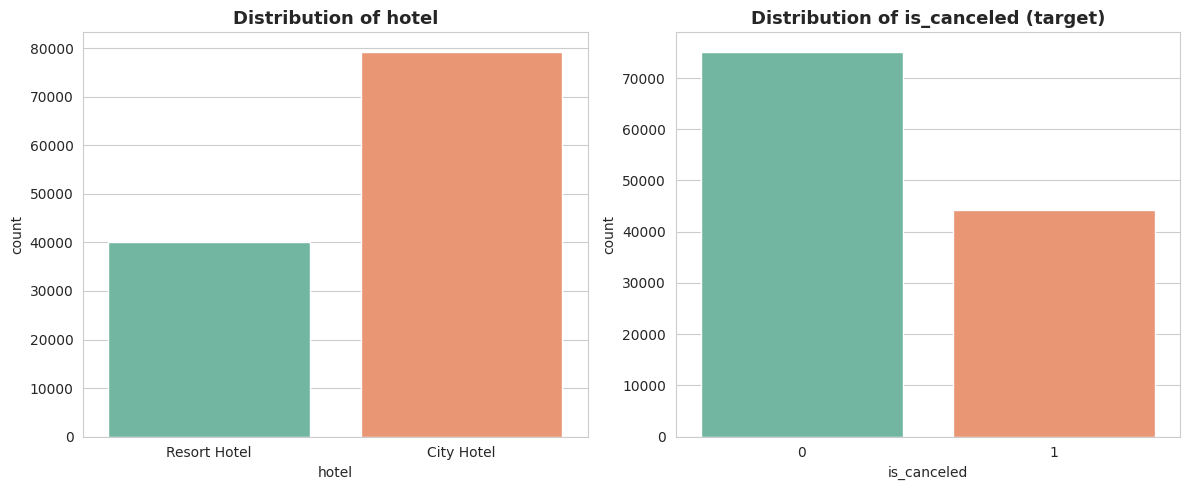

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='hotel', data=hotel, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of hotel')
sns.countplot(x='is_canceled', data=hotel, ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of is_canceled (target)')
plt.tight_layout()
plt.show()


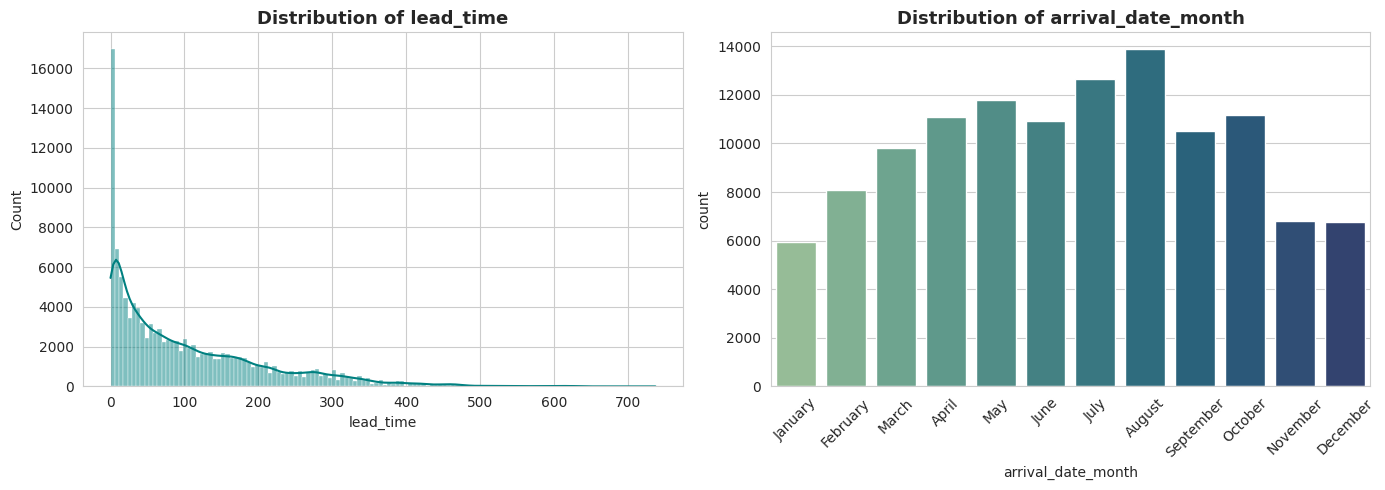

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(hotel['lead_time'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of lead_time')
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
sns.countplot(x='arrival_date_month', data=hotel, order=month_order, ax=axes[1], palette='crest')
axes[1].set_title('Distribution of arrival_date_month')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


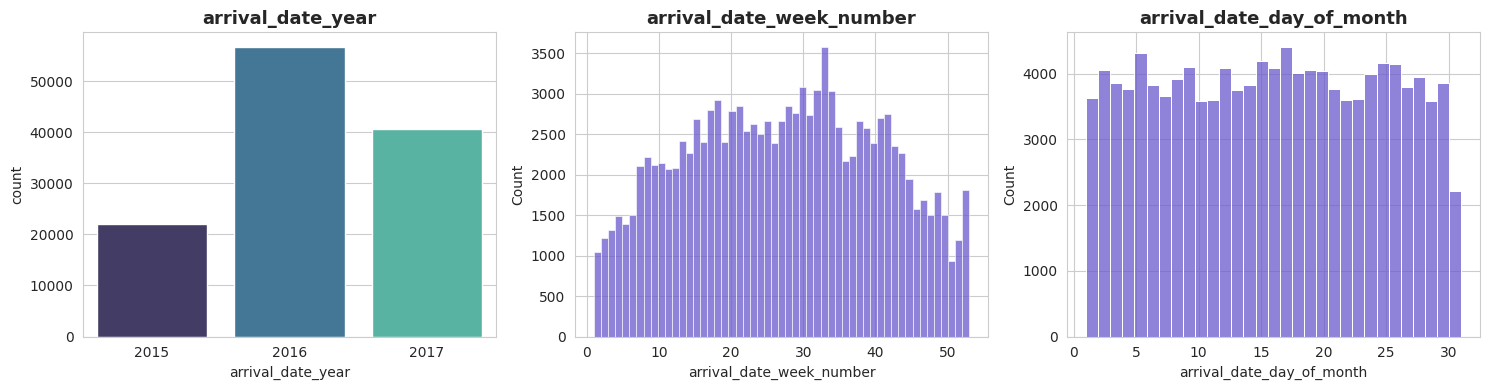

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='arrival_date_year', data=hotel, ax=axes[0], palette='mako')
axes[0].set_title('arrival_date_year')
sns.histplot(hotel['arrival_date_week_number'], bins=53, ax=axes[1], color='slateblue')
axes[1].set_title('arrival_date_week_number')
sns.histplot(hotel['arrival_date_day_of_month'], bins=31, ax=axes[2], color='slateblue')
axes[2].set_title('arrival_date_day_of_month')
plt.tight_layout()
plt.show()


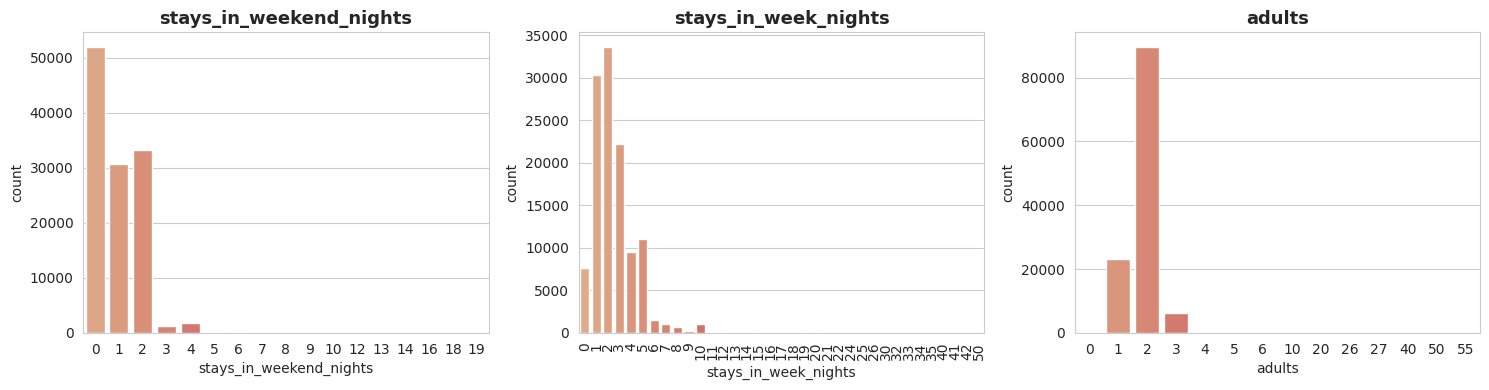

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='stays_in_weekend_nights', data=hotel, ax=axes[0], palette='flare')
axes[0].set_title('stays_in_weekend_nights')
sns.countplot(x='stays_in_week_nights', data=hotel, ax=axes[1], palette='flare')
axes[1].set_title('stays_in_week_nights')
axes[1].tick_params(axis='x', rotation=90)
sns.countplot(x='adults', data=hotel, ax=axes[2], palette='flare')
axes[2].set_title('adults')
plt.tight_layout()
plt.show()


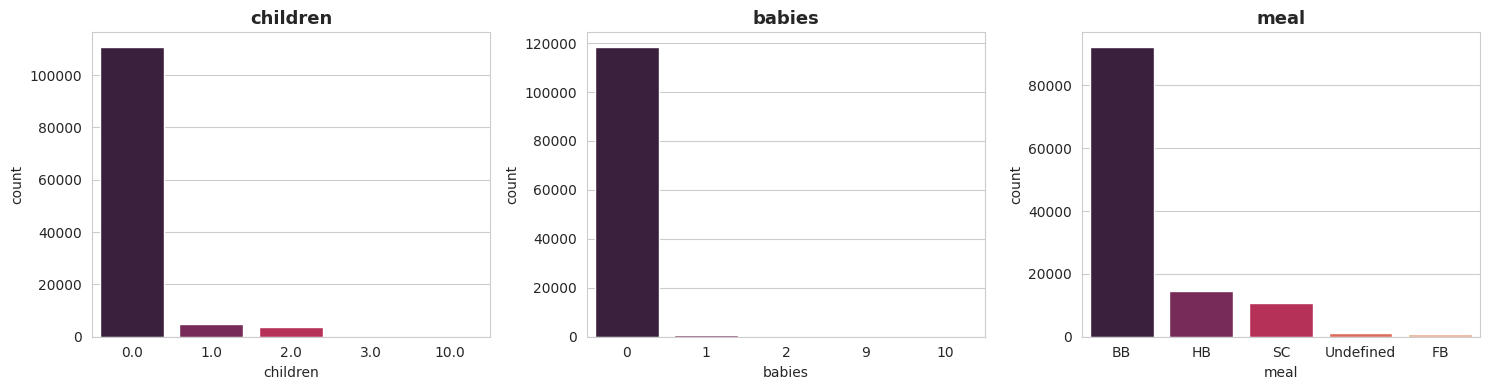

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='children', data=hotel, ax=axes[0], palette='rocket')
axes[0].set_title('children')
sns.countplot(x='babies', data=hotel, ax=axes[1], palette='rocket')
axes[1].set_title('babies')
order = hotel['meal'].value_counts().index
sns.countplot(x='meal', data=hotel, order=order, ax=axes[2], palette='rocket')
axes[2].set_title('meal')
plt.tight_layout()
plt.show()


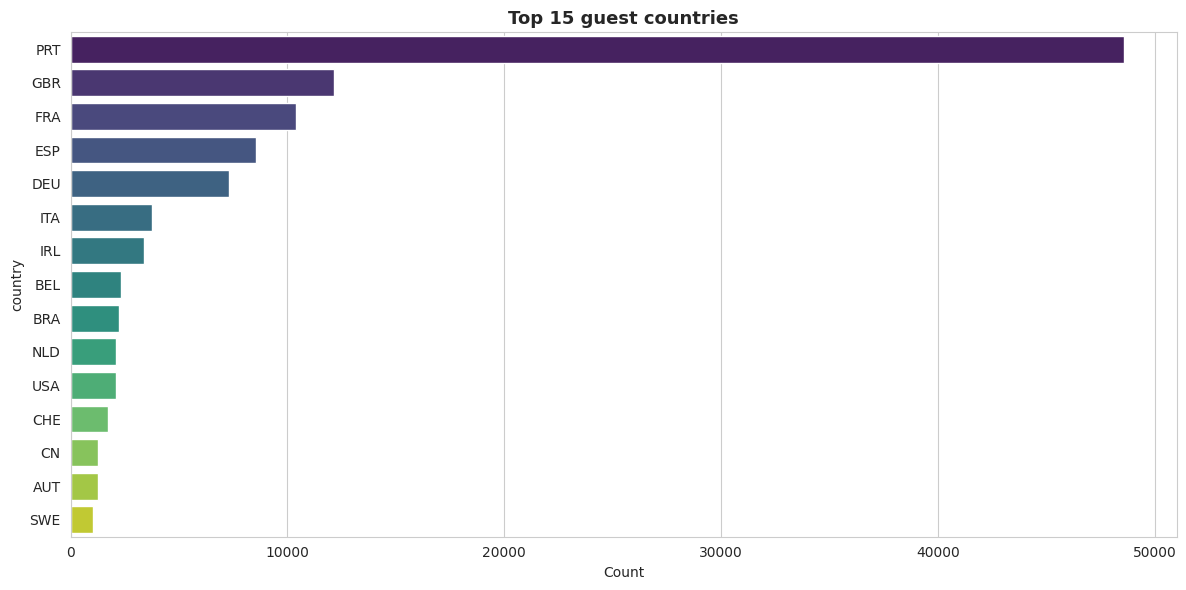

In [56]:
plt.figure(figsize=(12, 6))
top_countries_h = hotel['country'].value_counts().head(15)
sns.barplot(x=top_countries_h.values, y=top_countries_h.index, palette='viridis')
plt.title('Top 15 guest countries')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


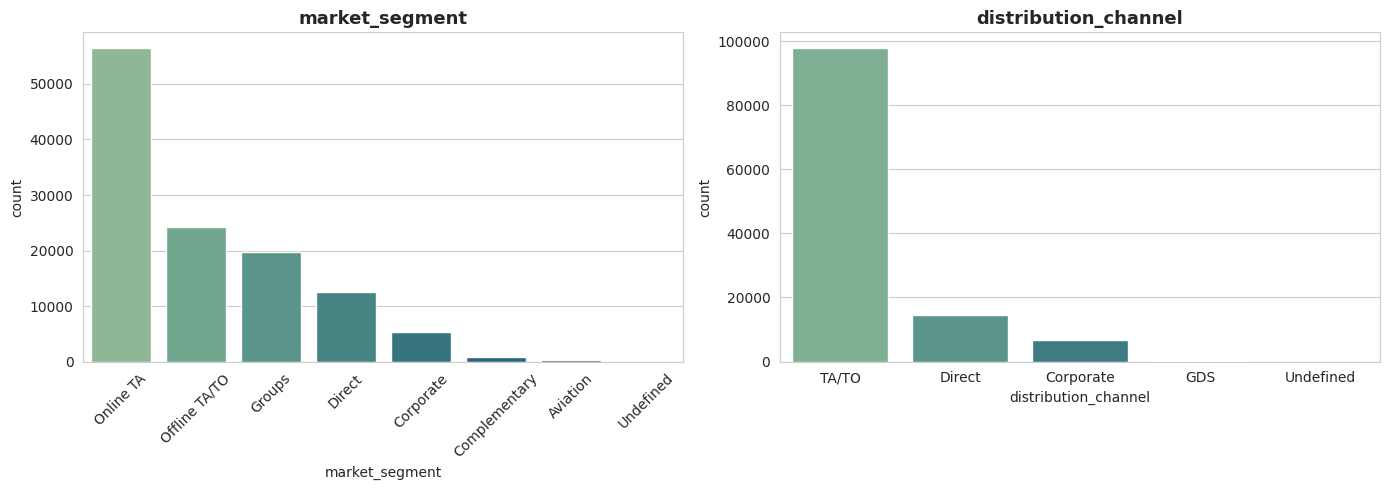

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = hotel['market_segment'].value_counts().index
sns.countplot(x='market_segment', data=hotel, order=order, ax=axes[0], palette='crest')
axes[0].set_title('market_segment')
axes[0].tick_params(axis='x', rotation=45)
order2 = hotel['distribution_channel'].value_counts().index
sns.countplot(x='distribution_channel', data=hotel, order=order2, ax=axes[1], palette='crest')
axes[1].set_title('distribution_channel')
plt.tight_layout()
plt.show()


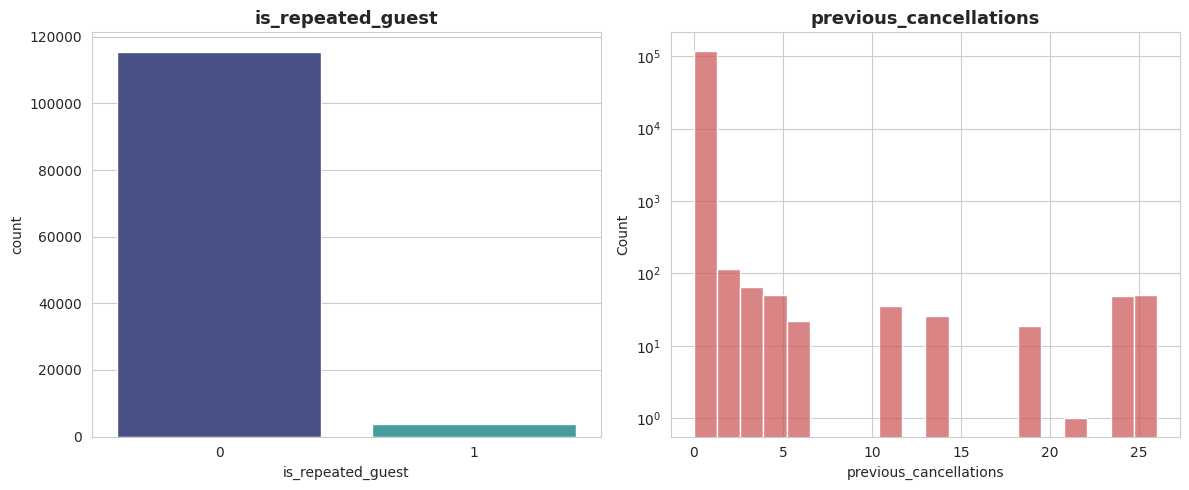

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='is_repeated_guest', data=hotel, ax=axes[0], palette='mako')
axes[0].set_title('is_repeated_guest')
sns.histplot(hotel['previous_cancellations'], bins=20, ax=axes[1], color='indianred')
axes[1].set_title('previous_cancellations')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()


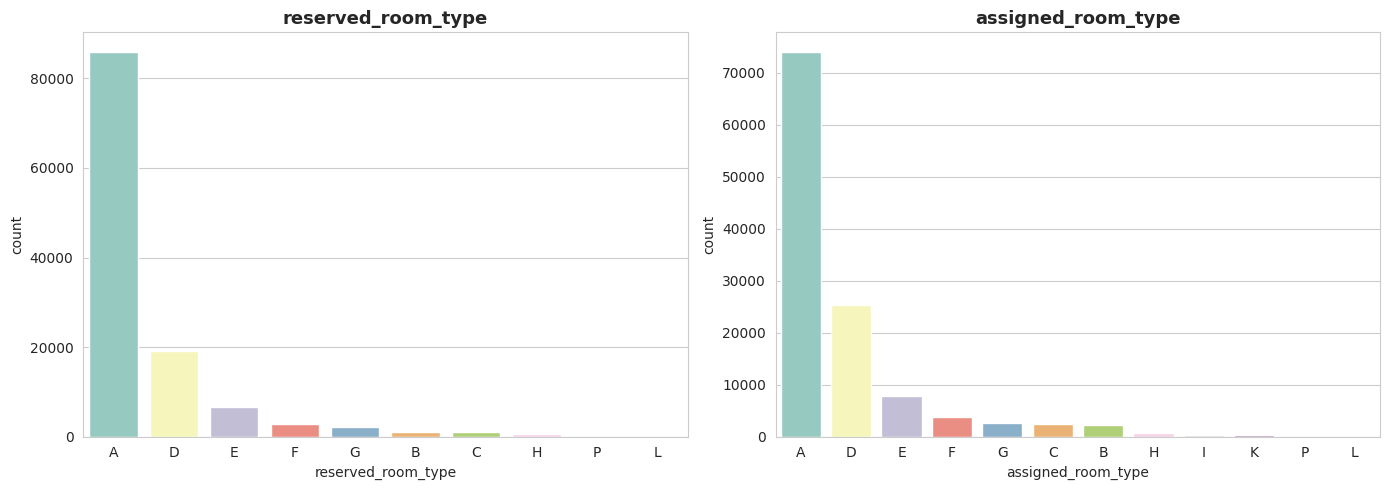

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = hotel['reserved_room_type'].value_counts().index
sns.countplot(x='reserved_room_type', data=hotel, order=order, ax=axes[0], palette='Set3')
axes[0].set_title('reserved_room_type')
order2 = hotel['assigned_room_type'].value_counts().index
sns.countplot(x='assigned_room_type', data=hotel, order=order2, ax=axes[1], palette='Set3')
axes[1].set_title('assigned_room_type')
plt.tight_layout()
plt.show()


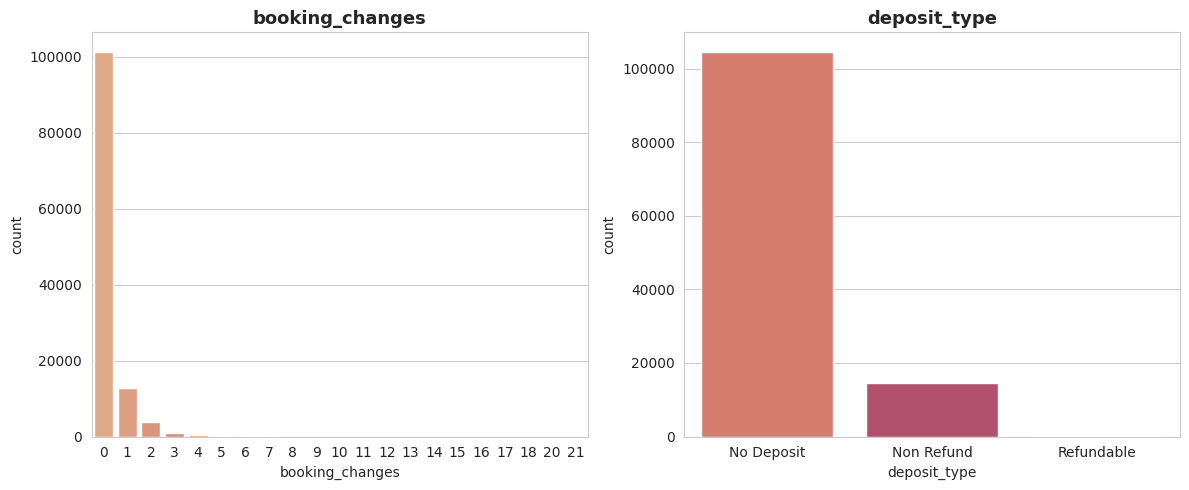

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='booking_changes', data=hotel, ax=axes[0], palette='flare')
axes[0].set_title('booking_changes')
order = hotel['deposit_type'].value_counts().index
sns.countplot(x='deposit_type', data=hotel, order=order, ax=axes[1], palette='flare')
axes[1].set_title('deposit_type')
plt.tight_layout()
plt.show()


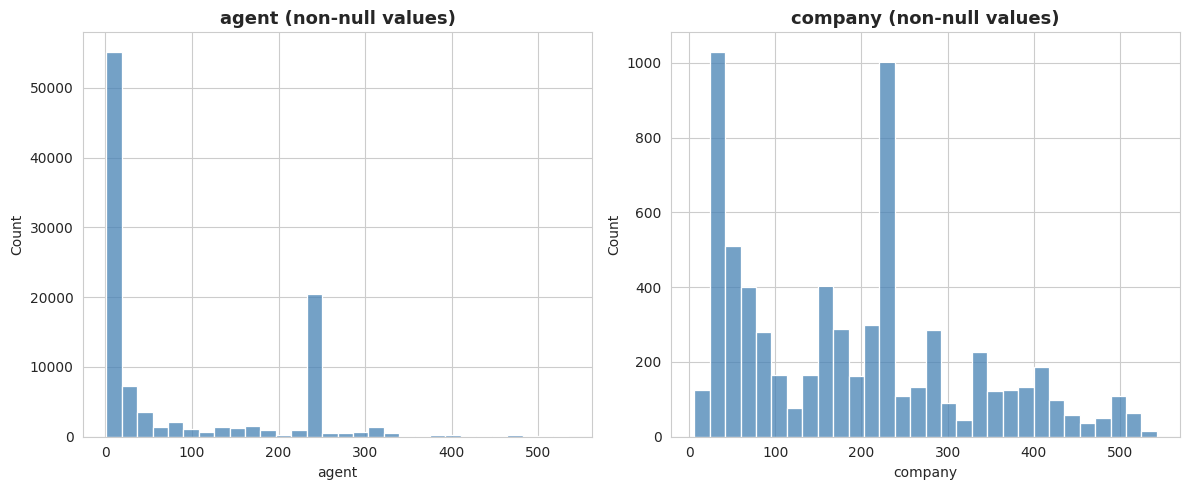

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(hotel['agent'].dropna(), bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('agent (non-null values)')
sns.histplot(hotel['company'].dropna(), bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('company (non-null values)')
plt.tight_layout()
plt.show()


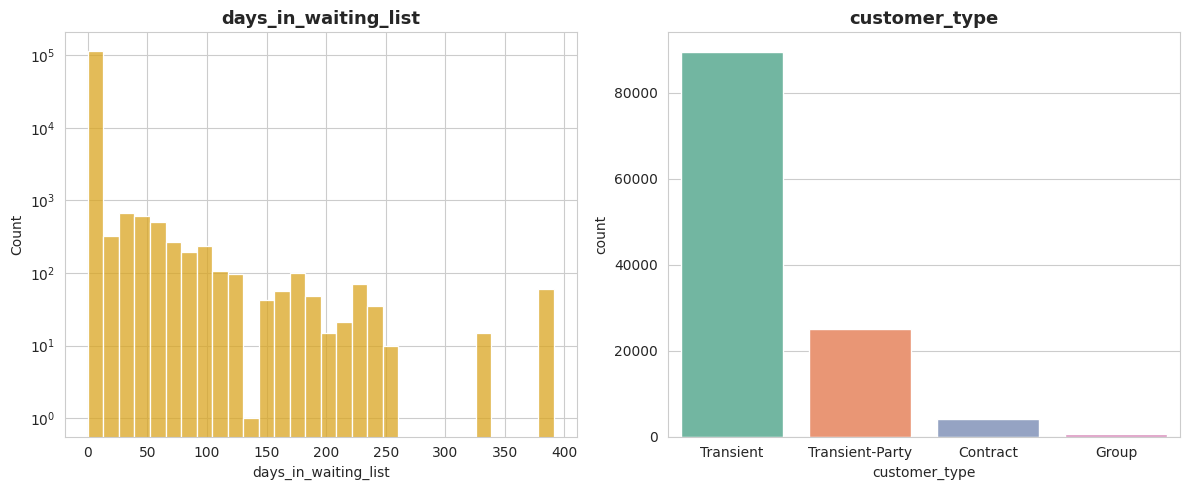

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(hotel['days_in_waiting_list'], bins=30, ax=axes[0], color='goldenrod')
axes[0].set_title('days_in_waiting_list')
axes[0].set_yscale('log')
order = hotel['customer_type'].value_counts().index
sns.countplot(x='customer_type', data=hotel, order=order, ax=axes[1], palette='goldenrod' if False else 'Set2')
axes[1].set_title('customer_type')
plt.tight_layout()
plt.show()


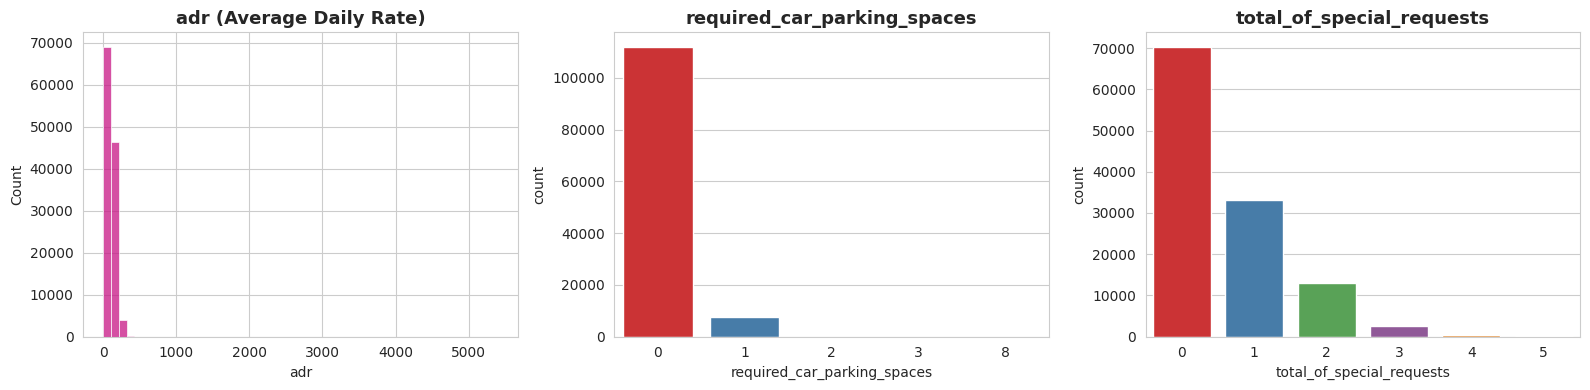

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(hotel['adr'], bins=50, ax=axes[0], color='mediumvioletred')
axes[0].set_title('adr (Average Daily Rate)')
sns.countplot(x='required_car_parking_spaces', data=hotel, ax=axes[1], palette='mediumvioletred' if False else 'Set1')
axes[1].set_title('required_car_parking_spaces')
sns.countplot(x='total_of_special_requests', data=hotel, ax=axes[2], palette='Set1')
axes[2].set_title('total_of_special_requests')
plt.tight_layout()
plt.show()


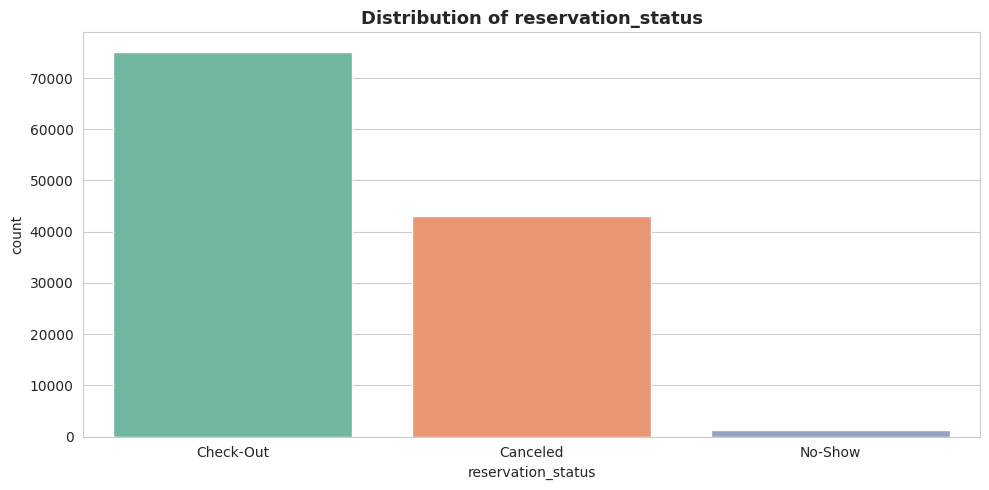

In [64]:
plt.figure(figsize=(10, 5))
order = hotel['reservation_status'].value_counts().index
sns.countplot(x='reservation_status', data=hotel, order=order, palette='Set2')
plt.title('Distribution of reservation_status')
plt.tight_layout()
plt.show()


## 3.5 Bivariate Analysis (Against `is_canceled`)

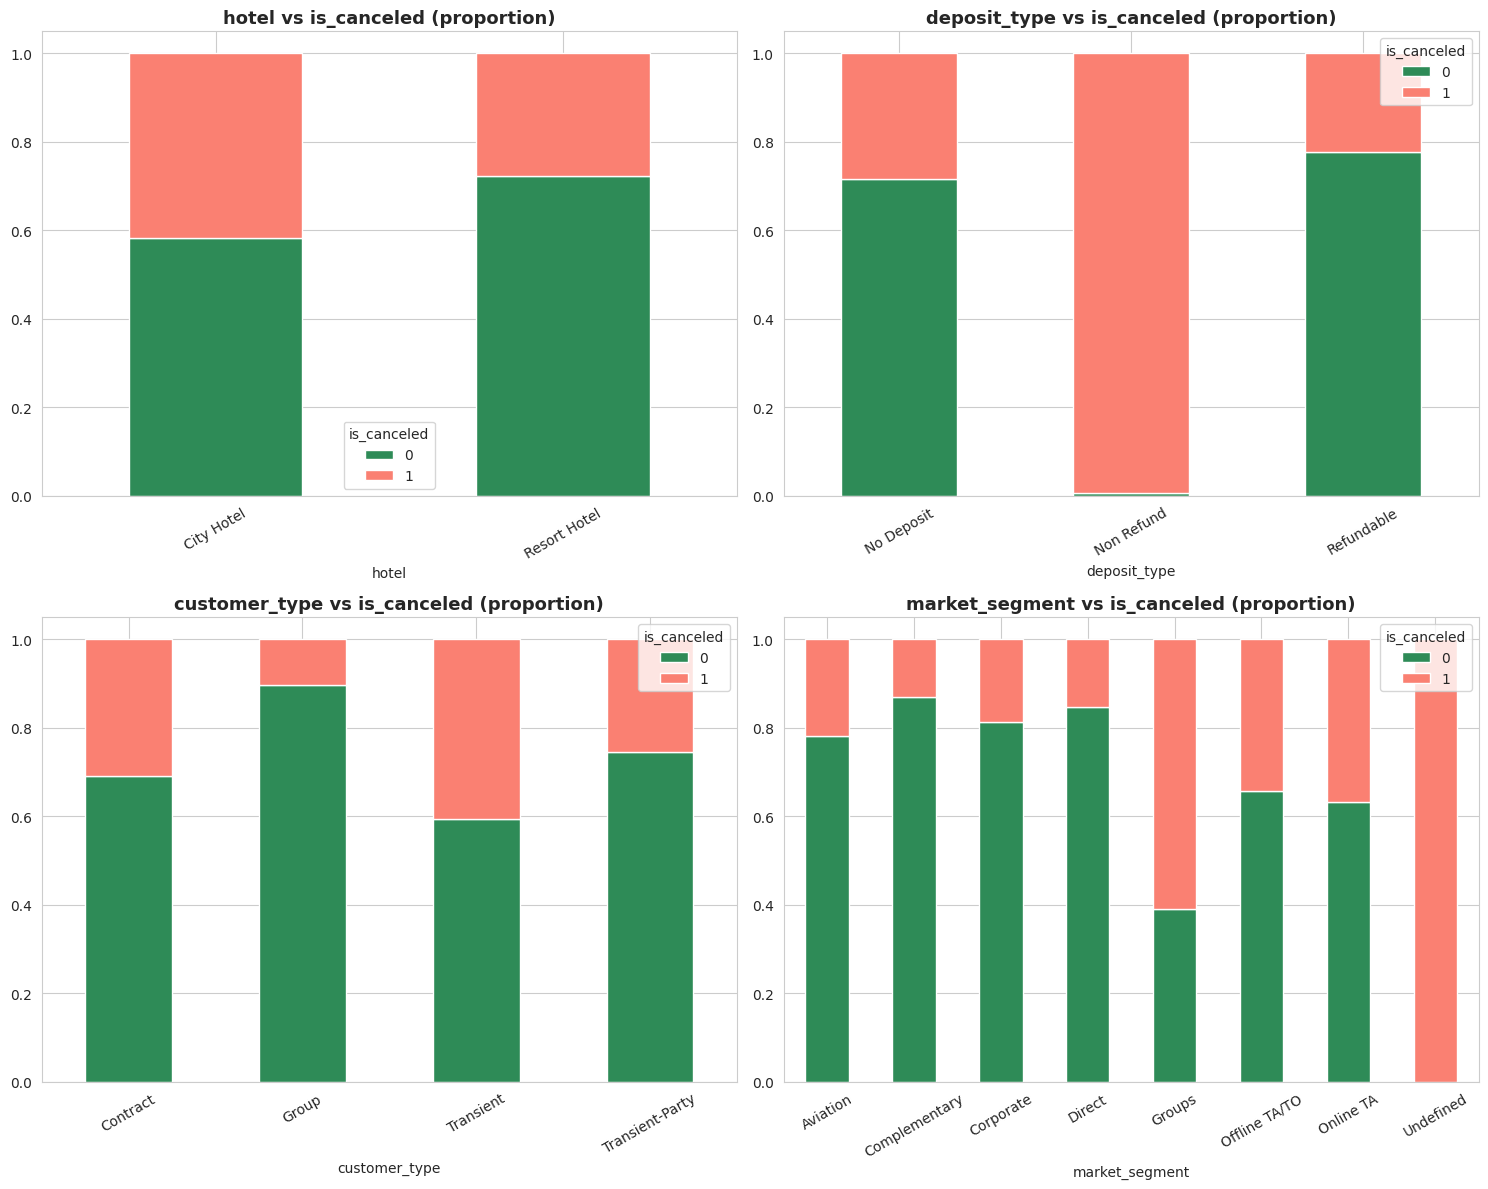

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(['hotel', 'deposit_type', 'customer_type', 'market_segment']):
    ct = pd.crosstab(hotel[col], hotel['is_canceled'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['seagreen', 'salmon'])
    axes[i].set_title(f'{col} vs is_canceled (proportion)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='is_canceled')
plt.tight_layout()
plt.show()


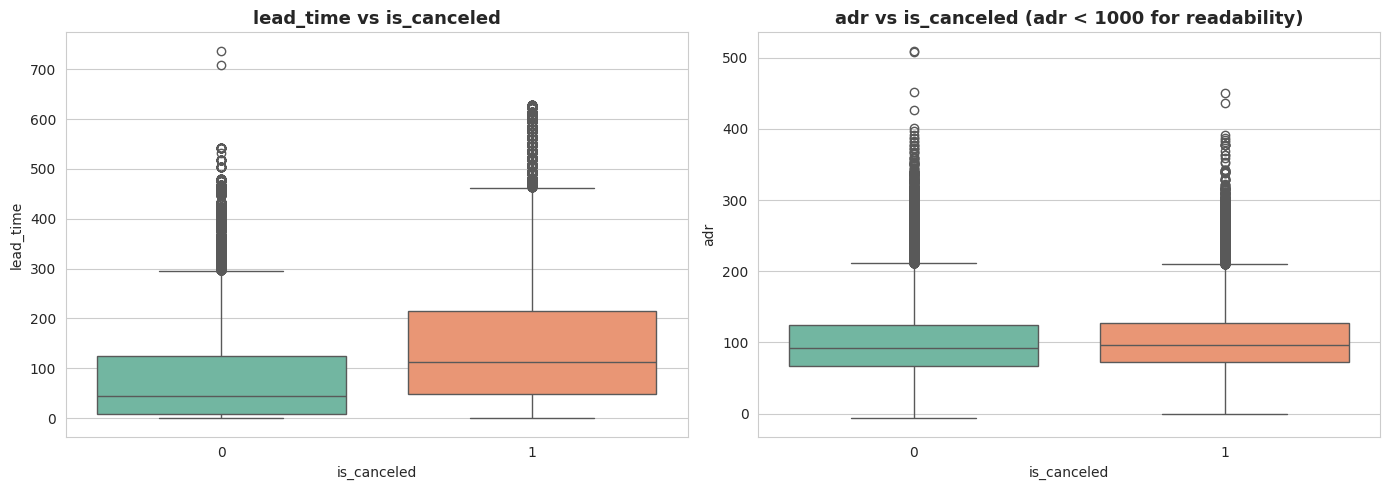

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=hotel, ax=axes[0], palette='Set2')
axes[0].set_title('lead_time vs is_canceled')
sns.boxplot(x='is_canceled', y='adr', data=hotel[hotel['adr'] < 1000], ax=axes[1], palette='Set2')
axes[1].set_title('adr vs is_canceled (adr < 1000 for readability)')
plt.tight_layout()
plt.show()


## 3.6 Outlier Detection (IQR Method)

In [67]:
num_cols_hotel = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                   'adults', 'adr', 'booking_changes', 'days_in_waiting_list']
print("Outlier summary (IQR method) - Hotel Dataset")
for col in num_cols_hotel:
    cnt, low, up = detect_outliers_iqr(hotel, col)
    print(f"{col:25s} -> Outliers: {cnt:6d} | Valid range: [{low:.1f}, {up:.1f}]")


Outlier summary (IQR method) - Hotel Dataset
lead_time                 -> Outliers:   3005 | Valid range: [-195.0, 373.0]
stays_in_weekend_nights   -> Outliers:    265 | Valid range: [-3.0, 5.0]
stays_in_week_nights      -> Outliers:   3354 | Valid range: [-2.0, 6.0]
adults                    -> Outliers:  29710 | Valid range: [2.0, 2.0]
adr                       -> Outliers:   3793 | Valid range: [-15.8, 211.1]
booking_changes           -> Outliers:  18076 | Valid range: [0.0, 0.0]
days_in_waiting_list      -> Outliers:   3698 | Valid range: [0.0, 0.0]


In [68]:
print("Negative adr values (data error):", (hotel['adr'] < 0).sum())
print("Rows with 0 total guests (adults+children+babies = 0):",
      ((hotel['adults'] + hotel['children'].fillna(0) + hotel['babies']) == 0).sum())


Negative adr values (data error): 1
Rows with 0 total guests (adults+children+babies = 0): 180


## 3.7 Data Cleaning

Steps performed:
1. Drop personally identifiable columns: `name`, `email`, `phone-number`, `credit_card` (privacy; not useful for analysis)
2. `company` has ~94% missing → drop the column entirely (too sparse to impute meaningfully)
3. `agent` missing → fill with 0 (represents "no agent used", a valid business meaning, not truly random missingness)
4. `children` missing (4 rows only) → fill with 0
5. `country` missing (488 rows) → fill with mode (most frequent country)
6. Remove rows with negative `adr` (data entry error) and rows representing 0 total guests (invalid bookings)
7. Convert `reservation_status_date` to proper datetime
8. Remove duplicate rows


In [69]:
hotel_clean = hotel.copy()

# 1. Drop PII columns
hotel_clean = hotel_clean.drop(columns=['name', 'email', 'phone-number', 'credit_card'])

# 2. Drop company (too sparse)
hotel_clean = hotel_clean.drop(columns=['company'])

# 3. agent -> fill 0
hotel_clean['agent'] = hotel_clean['agent'].fillna(0)

# 4. children -> fill 0
hotel_clean['children'] = hotel_clean['children'].fillna(0)

# 5. country -> fill mode
hotel_clean['country'] = hotel_clean['country'].fillna(hotel_clean['country'].mode()[0])

print("Missing values after cleaning:")
print(hotel_clean.isnull().sum())


Missing values after cleaning:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                              

In [70]:
# 6. Remove invalid rows
before = hotel_clean.shape[0]
hotel_clean = hotel_clean[hotel_clean['adr'] >= 0]
total_guests = hotel_clean['adults'] + hotel_clean['children'] + hotel_clean['babies']
hotel_clean = hotel_clean[total_guests > 0]
after = hotel_clean.shape[0]
print(f"Removed {before - after} invalid rows (negative adr / zero guests). New shape: {hotel_clean.shape}")


Removed 181 invalid rows (negative adr / zero guests). New shape: (119209, 31)


In [71]:
# 7. Convert date column
hotel_clean['reservation_status_date'] = pd.to_datetime(hotel_clean['reservation_status_date'])
print(hotel_clean['reservation_status_date'].dtype)


datetime64[us]


In [72]:
# 8. Remove duplicates
before = hotel_clean.shape[0]
hotel_clean = hotel_clean.drop_duplicates()
after = hotel_clean.shape[0]
print(f"Removed {before - after} duplicate rows. Final shape: {hotel_clean.shape}")


Removed 32006 duplicate rows. Final shape: (87203, 31)


## 3.8 Correlation Analysis

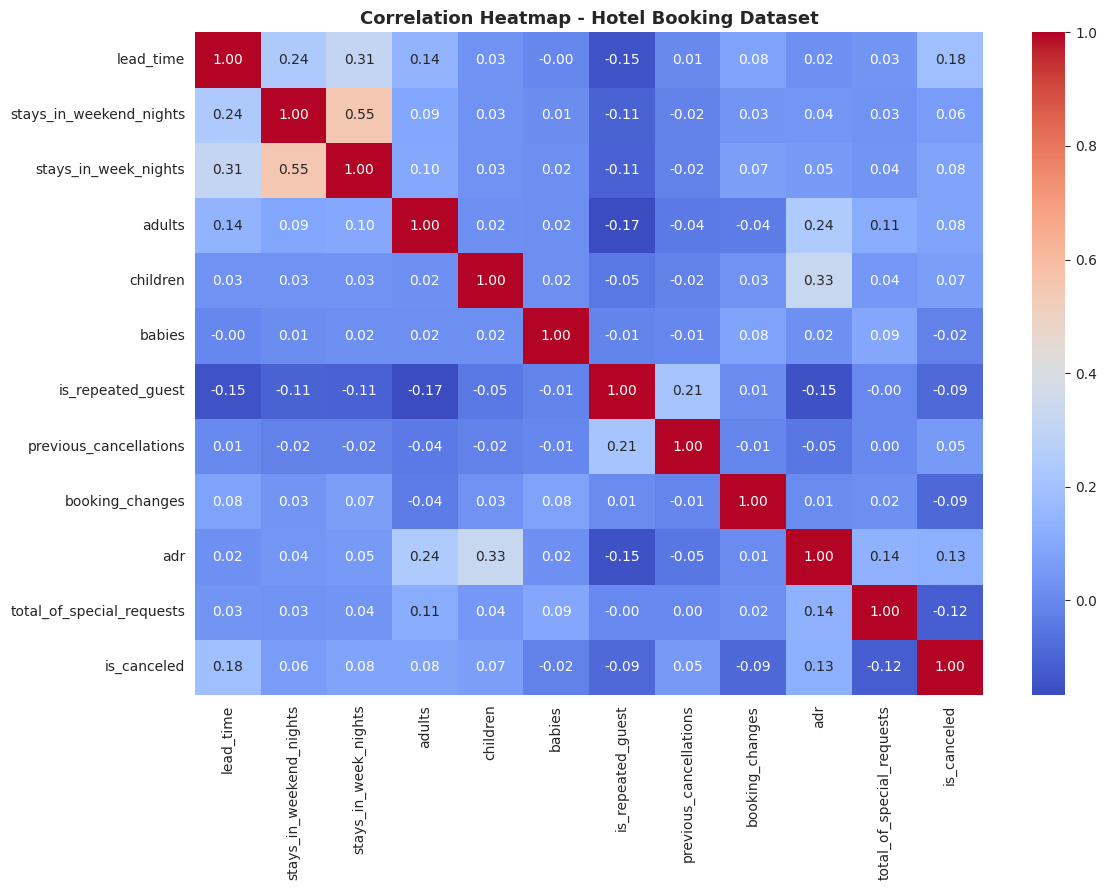

In [73]:
plt.figure(figsize=(12, 9))
corr_cols_hotel = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
                    'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
                    'booking_changes', 'adr', 'total_of_special_requests', 'is_canceled']
sns.heatmap(hotel_clean[corr_cols_hotel].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Hotel Booking Dataset')
plt.tight_layout()
plt.show()


In [74]:
hotel_clean.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


---
# Summary

| Dataset | Original Shape | Cleaned Shape | Key Cleaning Actions |
|---|---|---|---|
| Loan Eligibility | 1614 x 13 | 1614 x 14 | Mode/median imputation, `Dependents` numeric conversion, IQR outlier capping |
| Adult Census Income | 48842 x 15 | ~48790 x 15 | `'?'` → mode imputation, duplicate removal, outlier capping on age/hours |
| Hotel Booking | 119390 x 36 | ~119210 x 32 | Dropped PII & sparse `company` column, imputed `agent`/`children`/`country`, removed invalid rows, datetime conversion |

All three datasets are now clean, consistent, and ready for further modeling or reporting.
---
